# Integrative Metabolomics: An NIH Common Fund Data Ecosystem Workflow for Exploring MoTrPAC and Metabolomics Workbench Data

## Overview

In this notebook, you will use the **Metabolomics Workbench REST API** to identify, retrieve, and compare metabolomics studies related to exercise training. The workflow focuses on publicly available **MoTrPAC** rat heart metabolomics studies and an independent exercise-training study from the **Metabolomics Workbench** as a cross-study comparator.

This workflow identifies and downloads candidate Metabolomics Workbench studies, reviews study metadata and data structure, and identifies metabolites shared across datasets. It then characterizes shared metabolites based on their RefMet IDs, and then performs within-study as well as integrative analyses. Comments are included within code cells to explain the reasoning behind the provided code.

Because metabolomics studies can differ in experimental design, analytical platform, metabolite naming, data scale, and sample annotation, the workflow also emphasizes the importance of reviewing study metadata and data characteristics before making cross-study comparisons.

### Learning Objectives

By the end of this notebook, you will be able to:

1. **Use the Metabolomics Workbench REST API** to identify MoTrPAC studies and candidate comparator studies for cross-study metabolomics analysis.
2. **Extract and evaluate study data and metadata** to determine whether selected studies are suitable for comparison.
3. **Analyze shared metabolites across studies** using statistical, effect-size, metabolite classification, and directional-concordance approaches.

### Learning Assessments

Short multiple-choice assessments with answer keys are included throughout the notebook.

### Required Materials

This notebook requires a **Python 3.12 Jupyter environment** and installs the required Python packages at the beginning of the workflow. An internet connection is also required to access the Metabolomics Workbench REST API. 

The notebook can be run in environments such as **Google Colab, Jupyter Notebook/JupyterLab, or Visual Studio Code with the Jupyter extension**. 

<!-- ===================================================== -->
## Data Citation (Metabolomics Workbench / NMDR)

### Projects used in this notebook

| Data source | Studies used | Project ID | Project DOI | DOI Link |
|---|---:|---|---|---|
| Metabolomics Workbench / NMDR (MoTrPAC heart studies) | 13 | **PR001020** | **10.21228/M8V97D** | https://doi.org/10.21228/M8V97D |
| Metabolomics Workbench / NMDR (Comparator study) | 1 | **PR000623** | **10.21228/M84T25** | https://doi.org/10.21228/M84T25 |

---

### How to cite NMDR data used in this notebook

**MoTrPAC heart studies (Project PR001020):**  
This data is available at the NIH Common Fund's National Metabolomics Data Repository (NMDR) website, the Metabolomics Workbench, https://www.metabolomicsworkbench.org where it has been assigned Project ID **PR001020**. The data can be accessed directly via its Project DOI: **10.21228/M8V97D** (https://doi.org/10.21228/M8V97D). This work is supported by NIH grant **U2C-DK119886**.

**Comparator study (Project PR000623):**  
This data is available at the NIH Common Fund's National Metabolomics Data Repository (NMDR) website, the Metabolomics Workbench, https://www.metabolomicsworkbench.org where it has been assigned Project ID **PR000623**. The data can be accessed directly via its Project DOI: **10.21228/M84T25** (https://doi.org/10.21228/M84T25). This work is supported by NIH grant **U2C-DK119886**.

---

### How to cite Metabolomics Workbench as a general resource
“The Metabolomics Workbench, https://www.metabolomicsworkbench.org/”

<!-- ===================================================== -->

## 1) Setup

Run the cells below to install and import required Python packages, and configure the virtual and global environments.

In [1]:
# Configure the virtual environment
import sys

required_major = 3
required_minor = 12

if sys.version_info[:2] != (required_major, required_minor):
    raise RuntimeError(
        f"This notebook is intended for Python {required_major}.{required_minor}.x. "
        f"You are currently using Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}. "
        "Please switch to a Python 3.12 Jupyter kernel before continuing."
    )

print("This notebook is run most reliably on Python 3.12.x. If you are using a different version, please switch to a Python 3.12 Jupyter kernel before continuing.")
print("Python version:", sys.version)

This notebook is run most reliably on Python 3.12.x. If you are using a different version, please switch to a Python 3.12 Jupyter kernel before continuing.
Python version: 3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]


In [2]:
# Install required Python packages
%pip -q install \
    pandas==2.2.2 \
    numpy==2.0.2 \
    requests==2.32.4 \
    scipy==1.16.3 \
    statsmodels==0.14.6 \
    seaborn==0.13.2 \
    matplotlib==3.9.2 \
    matplotlib-venn==1.1.2 \
    plotly==5.24.1\
    nbformat==5.10.4

# Standard library imports
import glob
import json
import os
import re
import textwrap
import time

from io import StringIO
from typing import Any, Dict, List, Optional, Tuple

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import nbformat
import requests
import seaborn as sns

from IPython.display import display
from matplotlib_venn import venn2
from scipy.stats import combine_pvalues, hypergeom, ttest_ind
from statsmodels.stats.multitest import multipletests

# Configure display and plotting defaults
%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

print("Python packages imported.")

Note: you may need to restart the kernel to use updated packages.
Python packages imported.


In [3]:
# Configure the global environment

# `ALPHA` defines the statistical significance threshold used when evaluating p-values or adjusted p-values.
# `DATADIR` defines the top-level directory used for downloaded and intermediate data files.
# `OUTDIR` defines the top-level directory intended for generated analysis outputs.
# The directories are created automatically if they do not already exist.

# Statistical significance threshold used throughout the analysis
ALPHA = 0.05

# Top-level directories for downloaded data and generated outputs
DATADIR = "./data"
OUTDIR = "./outputs"

# Create directories if they do not already exist
os.makedirs(DATADIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

# Display the resolved directory locations
print("Data directory:", os.path.abspath(DATADIR))
print("Output directory:", os.path.abspath(OUTDIR))

Data directory: /Users/ericleslie/Projects/MoTrPAC_x_MetabolomicsWorkbench/data
Output directory: /Users/ericleslie/Projects/MoTrPAC_x_MetabolomicsWorkbench/outputs


## 2) Test Metabolomics Workbench API Connection

**Learning objective: 1**

The **Metabolomics Workbench REST service** provides programmatic access to study metadata, experimental results, metabolite information, RefMet annotations, and other resources hosted by the Metabolomics Workbench. HTTP requests can, therefore, be used to retrieve results rather than manual downloads from the website. 

Metabolomics Workbench REST service can be found here: `https://www.metabolomicsworkbench.org/tools/mw_rest.php`.

Metabolomics Workbench REST requests use of a common base URL: `https://www.metabolomicsworkbench.org/rest/`

The remainder of the URL specifies the type of information/data being requested, the identifier or search value, and the desired output. For example, a request for the summary of study `ST000001` follows the structure: `https://www.metabolomicsworkbench.org/rest/study/study_id/ST000001/summary`

In this notebook, we primarily use the **study** endpoints to search for studies and retrieve study summaries, analysis metadata, and metabolomics data tables. The REST service returns information in formats such as JSON or text that can be read directly into Python for downstream analysis. 

First, let's test that the REST service is reachable from the current Python environment.

In [4]:
# Test Metabolomics Workbench API connection

# Base URL for all Metabolomics Workbench REST API requests
MW_BASE = "https://www.metabolomicsworkbench.org/rest"

# Build a complete REST API URL from an endpoint
def mw_url(endpoint: str) -> str:
    return f"{MW_BASE}/{endpoint.lstrip('/')}"

# Send a request to the Metabolomics Workbench REST API
# and return either JSON or plain text, depending on the response
def mw_get_json_or_text(endpoint: str, timeout: int = 60) -> Tuple[str, Any]:
    url = mw_url(endpoint)

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    try:
        return url, response.json()
    except Exception:
        return url, response.text

# Configure retry behavior for temporary connection failures
RETRY_VERBOSE = False

def mw_get_json_or_text_retry(
    endpoint: str,
    timeout: int = 60,
    retries: int = 8,
    backoff: float = 1.5,
    verbose: bool = RETRY_VERBOSE
):
    last_error = None

    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)

        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as error:

            last_error = error

            # Exponential backoff:
            # wait progressively longer before each retry
            sleep_seconds = backoff * (2 ** attempt)

            if verbose:
                print(
                    f"[retry {attempt + 1}/{retries}] "
                    f"{endpoint} -> {error} | "
                    f"sleeping {sleep_seconds:.1f}s"
                )

            time.sleep(sleep_seconds)

    raise last_error

# Connectivity check:
# retrieve the summary for a known Metabolomics Workbench study
url, obj = mw_get_json_or_text("study/study_id/ST000759/summary")

print(
    "Test of Metabolomics Workbench API querying successful:",
    url
)

Test of Metabolomics Workbench API querying successful: https://www.metabolomicsworkbench.org/rest/study/study_id/ST000759/summary


## 3) Search Metabolomics Workbench (MW) for **MoTrPAC** Studies

Learning Objective: 1

**MoTrPAC** is a large NIH-funded research program designed to map the molecular response to exercise in humans and rats.

The Metabolomics Workbench is a NIH data repository for metabolomics data, including **MoTrPAC** data.

In this section, we will first identify **MoTrPAC** studies available through the Metabolomics Workbench. These studies will later be used to identify and compare metabolomics data from comparable studies on the **Metabolomics Workbench**.

First, we will find **MoTrPAC** data via keywords (e.g., **“MoTrPAC”**, **“Molecular Transducers of Physical Activity”**).  

### Reference: **MoTrPAC** young adult rat endurance training study IDs (MW)
Future **Metabolomics Workbench** studies may include **MoTrPAC** in the study title and use **MoTrPAC** data, even though they may not be the original **MoTrPAC** data sets. Therefore, this search query may have expanded results with non-**MoTrPAC**-specific data.

The following **Metabolomics Workbench** study IDs correspond to the original **MoTrPAC young adult rat endurance exercise training** metabolomics data sets (n = 113) provided by the **MoTrPAC** Consortium for public release on the **Metabolomics Workbench**:

ST002579, ST002580, ST002581, ST002582, ST002583, ST002588, ST002589, ST002590, ST002591, ST002592, ST002593, ST002594, ST002595, ST002596, ST002597, ST002598, ST002599, ST002600, ST002601, ST002602, ST002603, ST002604, ST002605, ST002606, ST002607, ST002608, ST002609, ST002610, ST002611, ST002612, ST002613, ST002614, ST002615, ST002616, ST002617, ST002618, ST002619, ST002620, ST002621, ST002622, ST002623, ST002624, ST002625, ST002626, ST002627, ST002628, ST002629, ST002630, ST002631, ST002632, ST002633, ST002634, ST002635, ST002636, ST002637, ST002638, ST002639, ST002640, ST002641, ST002642, ST002643, ST002644, ST002645, ST002646, ST002647, ST002648, ST002649, ST002650, ST002651, ST002652, ST002653, ST002654, ST002655, ST002656, ST002657, ST002658, ST002659, ST002660, ST002661, ST002662, ST002663, ST002664, ST002665, ST002666, ST002667, ST002668, ST002669, ST002670, ST002671, ST002672, ST002673, ST002674, ST002675, ST002676, ST002677, ST002678, ST002679, ST002680, ST002682, ST002683, ST002684, ST002685, ST002686, ST002687, ST002688, ST002689, ST002690, ST002691, ST002693, ST002694, ST002695, ST002915, ST002916

### How to use the table output
The search results are displayed as a **pandas DataFrame** containing the Metabolomics Workbench study IDs and study titles returned by the keyword search.

You can:
- Scroll through the displayed rows to review candidate studies;
- Compare the returned study IDs with the reference list above; and
- Use the study IDs in later sections to retrieve additional metadata and metabolomics data through the Metabolomics Workbench REST API.

Some notebook environments, including Google Colab and VS Code, also provide interactive DataFrame viewers that allow you to sort, filter, or inspect the table in greater detail.

In [5]:
# Search Metabolomics Workbench for candidate MoTrPAC studies

# Parse tab-separated text returned by the API into a pandas DataFrame
def try_parse_tsv(text: str) -> Optional[pd.DataFrame]:
    lines = [line for line in text.splitlines() if line.strip()]

    if len(lines) < 2:
        return None

    if "\t" in lines[0] and len(lines[0].split("\t")) >= 2:
        return pd.read_csv(StringIO(text), sep="\t")

    return None

# Extract Metabolomics Workbench study accessions (ST######)
# from text, dictionaries, tables, or other API responses
def extract_st_ids(obj: Any) -> List[str]:
    return sorted(set(re.findall(r"\bST\d{6}\b", str(obj))))

# Extract a study title from a Metabolomics Workbench summary response
def extract_title_from_summary(summary: Any) -> Optional[str]:
    if isinstance(summary, dict):

        # Check commonly used title fields first
        for key in ["study_title", "Study Title", "title", "Title", "study", "Study"]:
            if key in summary and summary[key]:
                return str(summary[key])

        # Fallback: use another field containing the word "title"
        for key in summary:
            if "title" in key.lower() and summary[key]:
                return str(summary[key])

    return None

def mw_search_motrpac_studies(keywords=None, save_csv=True):
    """
    Search Metabolomics Workbench study titles for candidate MoTrPAC studies.

    The function:
      1. searches study titles using MoTrPAC-related keywords,
      2. extracts unique Metabolomics Workbench study IDs,
      3. retrieves the summary for each study,
      4. extracts the study title,
      5. optionally saves the results as a CSV file, and
      6. returns both the results table and a list of study IDs.
    """

    if keywords is None:
        keywords = ["MoTrPAC", "Molecular Transducers of Physical Activity"]

    # Search study titles and collect candidate ST accessions
    st_ids = set()

    for keyword in keywords:
        endpoint = f"study/study_title/{requests.utils.quote(keyword)}/summary"

        response = mw_get_json_or_text(endpoint, timeout=60)

        if isinstance(response, str):
            parsed_table = try_parse_tsv(response)

            st_ids |= set(
                extract_st_ids(
                    parsed_table if parsed_table is not None else response
                )
            )
        else:
            st_ids |= set(extract_st_ids(response))

    st_ids = sorted(st_ids)

    print("Keywords searched:", keywords)
    print("Candidate MoTrPAC studies found:", len(st_ids))

    # Retrieve the study title for each candidate accession
    rows = []

    for study_id in st_ids:
        _, summary = mw_get_json_or_text(
            f"study/study_id/{study_id}/summary",
            timeout=60
        )

        rows.append({
            "study_id": study_id,
            "title": extract_title_from_summary(summary)
        })

    motrpac_studies_df = (
        pd.DataFrame(rows)
        .drop_duplicates("study_id")
        .sort_values("study_id")
        .reset_index(drop=True)
    )

    # Optionally save the candidate-study table
    if save_csv:
        os.makedirs("./data/mw", exist_ok=True)

        motrpac_studies_df.to_csv(
            "./data/mw/motrpac_studies.csv",
            index=False
        )

    display(motrpac_studies_df)

    # Create a simple list of accessions for downstream analyses
    motrpac_study_ids = motrpac_studies_df["study_id"].tolist()

    return motrpac_studies_df, motrpac_study_ids

# Run the search
motrpac_studies_df, motrpac_study_ids = mw_search_motrpac_studies()

Keywords searched: ['MoTrPAC', 'Molecular Transducers of Physical Activity']
Candidate MoTrPAC studies found: 113


,study_id,title
0,ST002579,MoTrPAC: Endurance exercise training study in ...
1,ST002580,MoTrPAC: Endurance exercise training study in ...
2,ST002581,MoTrPAC: Endurance exercise training study in ...
3,ST002582,MoTrPAC: Endurance exercise training study in ...
4,ST002583,MoTrPAC: Endurance exercise training study in ...
...,...,...
108,ST002693,MoTrPAC: Endurance exercise training study in ...
109,ST002694,MoTrPAC: Endurance exercise training study in ...
110,ST002695,MoTrPAC: Endurance exercise training study in ...
111,ST002915,MoTrPAC: Endurance exercise training study in ...


## 4) Search Metabolomics Workbench for Comparable Studies to MoTrPAC

**Learning Objective: 1**

In the previous section, we identified MoTrPAC studies available through the Metabolomics Workbench. We will now search for other metabolomics studies that may be suitable for comparison with the MoTrPAC young adult rat endurance exercise training data.

The goal of this section is to compile a list of candidate studies that can be evaluated for comparison with the MoTrPAC datasets in the next section.

Candidacy is defined as studies that include **rats** and **exercise or endurance training**.

The search uses study titles and metadata to identify **candidate comparator studies**. Because terminology and study descriptions can vary across Metabolomics Workbench submissions, the resulting studies should be reviewed for experimental design, tissue, study groups, and data type before being included in an analysis.

In [6]:
# Search Metabolomics Workbench for studies comparable to MoTrPAC

# Convert a study-summary response to lowercase text for keyword matching
def summary_text(summary: Any) -> str:
    return str(summary).lower()

# Keywords used to identify candidate rat exercise-training studies
EXERCISE_KEYWORDS = [
    "exercise",
    "training",
    "trained",
    "treadmill",
    "endurance",
    "running",
    "aerobic"
]

RAT_KEYWORDS = [
    "rat",
    "rattus",
    "sprague",
    "dawley",
    "wistar",
    "long-evans",
    "long evans"
]

# Exclude studies that reference MoTrPAC itself
EXCLUDE_KEYWORDS = [
    "motrpac",
    "molecular transducers of physical activity"
]

# Terms used for the initial Metabolomics Workbench title search
SEARCH_TERMS = [
    "exercise",
    "training",
    "treadmill",
    "endurance"
]

# Create a set of MoTrPAC study IDs identified in Section 3
MOTRPAC_ST_SET = set(
    motrpac_studies_df["study_id"]
    .dropna()
    .astype(str)
    .unique()
)

# Search Metabolomics Workbench study titles using the specified terms
def search_title_terms_get_st_ids(terms: List[str]) -> List[str]:
    study_ids = set()

    for term in terms:
        endpoint = (
            f"study/study_title/"
            f"{requests.utils.quote(term)}/summary"
        )

        # mw_get_json_or_text() returns (URL, response)
        _, response = mw_get_json_or_text(endpoint, timeout=60)

        if isinstance(response, str):
            parsed_table = try_parse_tsv(response)

            study_ids |= set(
                extract_st_ids(
                    parsed_table
                    if parsed_table is not None
                    else response
                )
            )

        else:
            study_ids |= set(extract_st_ids(response))

    return sorted(study_ids)

# Perform the broad title search
candidate_studies = search_title_terms_get_st_ids(SEARCH_TERMS)

print(
    "Initial candidate study count (pre-filter):",
    len(candidate_studies)
)

# Filter candidates using species- and exercise-related metadata
rows = []

for study_id in candidate_studies:
    # Skip studies already identified as MoTrPAC
    if study_id in MOTRPAC_ST_SET:
        continue

    try:
        # Retrieve the study summary
        _, summary = mw_get_json_or_text(
            f"study/study_id/{study_id}/summary",
            timeout=60
        )

        title = extract_title_from_summary(summary)
        summary_blob = summary_text(summary)

        # Determine whether the study appears to involve rats
        is_rat = (
            any(keyword in summary_blob for keyword in RAT_KEYWORDS)
            or "rat" in (title or "").lower()
        )

        # Determine whether the study appears to involve exercise training
        is_exercise = (
            any(keyword in summary_blob for keyword in EXERCISE_KEYWORDS)
            or any(
                keyword in (title or "").lower()
                for keyword in EXERCISE_KEYWORDS
            )
        )

        # Exclude studies that reference MoTrPAC
        is_excluded = (
            any(keyword in summary_blob for keyword in EXCLUDE_KEYWORDS)
            or any(
                keyword in (title or "").lower()
                for keyword in EXCLUDE_KEYWORDS
            )
        )

        # Retain studies meeting the comparator-search criteria
        if is_rat and is_exercise and not is_excluded:
            rows.append({
                "study_id": study_id,
                "title": title
            })

    except Exception:
        continue

# Compile candidate comparator studies
non_motrpac_rat_ex_df = (
    pd.DataFrame(rows)
    .drop_duplicates("study_id")
    .sort_values("study_id")
    .reset_index(drop=True)
)

print(
    "Candidate rat exercise-training studies comparable to MoTrPAC:",
    non_motrpac_rat_ex_df.shape[0]
)

display(non_motrpac_rat_ex_df)

Initial candidate study count (pre-filter): 154
Candidate rat exercise-training studies comparable to MoTrPAC: 13


,study_id,title
0,ST000759,Age and exercise effect on metabolomics in rats
1,ST000762,Plasma Nucleotide/adenosine concentrations in ...
2,ST000897,Untargeted metabolomics analysis of ischemia-r...
3,ST001068,The proteomic and metabolomic characterization...
4,ST001070,The global proteomic characterization of exerc...
5,ST001072,The in-gel proteomic characterization of exerc...
6,ST001526,Mitochondrial health is enhanced in rats with ...
7,ST001780,Comparative analysis of metabolomic profiles i...
8,ST001808,Impact of high intensity and moderate exercise...
9,ST001907,Training-induced bioenergetic improvement in h...


---

## Learning Assessments (Learning Objective 1)

**Q1. Which endpoint is used in Section 2 to test whether the Metabolomics Workbench REST API is reachable?**

A. `refmet/match/ST000759`  
B. `study/study_id/ST000759/analysis`  
C. `study/study_id/ST000759/summary`  
D. `study/study_title/ST000759/summary`

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: C**

- **A (Incorrect):** `refmet/match` is used for metabolite-name matching, not for retrieving a study summary. `ST000759` is also a study accession, not a metabolite name.
- **B (Incorrect):** `/analysis` retrieves analysis metadata, but this is not the endpoint used for the connectivity test.
- **C (Correct):** The connectivity test requests the summary for the known Metabolomics Workbench study accession `ST000759`.
- **D (Incorrect):** `/study_title/.../summary` searches studies using a title string rather than retrieving a study by its accession.

</details>

**Q2. Why should the keyword search in Section 3 be treated as a search for candidate MoTrPAC studies rather than a definitive list of original MoTrPAC datasets?**

A. Study titles or metadata may mention MoTrPAC even when the study is not an original MoTrPAC dataset, such as when MoTrPAC data are referenced or reused.  
B. The `/study_title/.../summary` endpoint only returns targeted metabolomics studies.  
C. The Metabolomics Workbench API automatically limits searches for “MoTrPAC” to rat studies.  
D. Keyword searches only return results when a specific ST accession is provided.

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** A study can mention MoTrPAC in its title or metadata without being one of the original MoTrPAC datasets, so keyword matches should be treated as candidates that require review.
- **B (Incorrect):** The study-title search endpoint is not restricted to targeted metabolomics studies.
- **C (Incorrect):** The API does not automatically restrict a MoTrPAC keyword search to rat studies; any species or study-type filtering must be performed by the workflow.
- **D (Incorrect):** Study-title keyword searches can return results without providing a specific ST accession.

</details>

## 5) Compare and Contrast MoTrPAC and a Selected Comparator Study

**Learning Objective: 2**

In this section, we will evaluate the **MoTrPAC heart metabolomics studies** together with one of the candidate comparator studies, **ST000897**, to determine how the datasets can be prepared for downstream cross-study analysis.

Since studies deposited in the Metabolomics Workbench may differ in experimental design, sample annotations, metabolomics platforms, and data scale, we will examine all of these before any analyses are performed. 

The section is organized into six parts with increasing granularity of study information/data:

- **Part 1: Summarize selected heart metabolomics studies**  
  Review study titles, tissue, targeted or untargeted metabolomics type, sample counts, sex distribution, and available grouping variables.

- **Part 2: Review study-group metadata**  
  Inspect the experimental group, timepoint, sex, and tissue levels available for each selected study.

- **Part 3: Download selected study data**  
  Retrieve and save the Metabolomics Workbench datatables used for the downstream analysis.

- **Part 4: Preview study design and metadata**  
  Examine representative study summaries, analysis metadata, sample counts, and class labels to better understand each experimental design.

- **Part 5: Preview metabolomics data**  
  Inspect representative variables, data types, and values from each downloaded study before performing transformations or statistical analyses.

- **Part 6: Diagnose data scale and transformation requirements**  
  Examine value distributions and metadata for evidence of normalization or transformation, and identify whether additional transformation may be appropriate before comparing studies.

In [7]:
# Part 1: Summary overview of heart metabolomics studies

# Confirm that required objects from earlier sections are available
assert "motrpac_studies_df" in globals(), (
    "Run the MoTrPAC study-search section first to create motrpac_studies_df."
)

assert "mw_get_json_or_text" in globals(), (
    "mw_get_json_or_text() is not defined. "
    "Run the Metabolomics Workbench API setup section first."
)

# Selected non-MoTrPAC comparator study
COMPARATOR_STUDY_ID = "ST000897"

# Extract Metabolomics Workbench analysis accessions (AN######)
def extract_an_ids(obj) -> list[str]:
    return sorted(set(re.findall(r"\bAN\d{6}\b", str(obj))))

# Extract a study title from a Metabolomics Workbench summary response
def get_title_from_summary(summary: dict) -> str:
    for key in ["study_title", "Study Title", "title", "Title", "study", "Study"]:
        if isinstance(summary, dict) and summary.get(key):
            return str(summary[key])

    return "(title not found)"

# Infer whether a study is targeted or untargeted from its title
def infer_targeted_from_title(title: str) -> str:
    title_lower = (title or "").lower()

    # Check "untargeted" first because it also contains the word "targeted"
    if "untargeted" in title_lower:
        return "untargeted"

    if "targeted" in title_lower:
        return "targeted"

    return "unknown"

# Infer tissue type from the study title
def infer_tissue_from_title(title: str) -> str:
    match = re.search(r"tissue\s*:\s*([^,-]+)", title, flags=re.IGNORECASE)

    if match:
        return match.group(1).strip()

    if "heart" in (title or "").lower():
        return "Heart"

    return "unknown"

# Parse the Metabolomics Workbench "Class" field into key-value metadata
def parse_class_field(value: str) -> dict:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return {}

    parsed = {}

    for part in str(value).split("|"):
        part = part.strip()

        if ":" in part:
            key, val = part.split(":", 1)
            parsed[key.strip()] = val.strip()

    return parsed

# Check whether an API response appears to contain tab-separated data
def looks_like_tsv(text: str) -> bool:
    lines = [line for line in str(text).splitlines() if line.strip()]

    return len(lines) >= 2 and "\t" in lines[0]

# Convert tab-separated text into a pandas DataFrame
def parse_tsv(text: str) -> pd.DataFrame:
    return pd.read_csv(StringIO(text), sep="\t")

# Retry Metabolomics Workbench API requests when temporary network or server errors occur
def mw_get_json_or_text_retry(endpoint: str, timeout: int = 60, retries: int = 8, backoff: float = 1.5):
    last_error = None

    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)

        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as error:

            last_error = error
            sleep_seconds = backoff * (2 ** attempt)

            print(
                f"[retry {attempt + 1}/{retries}] "
                f"{endpoint} -> {error} | "
                f"sleeping {sleep_seconds:.1f}s"
            )

            time.sleep(sleep_seconds)

    raise last_error

# Retrieve a datatable for one Metabolomics Workbench analysis accession
def get_datatable_for_an(an_id: str, timeout: int = 180, polite_sleep: float = 0.5) -> pd.DataFrame | None:
    if polite_sleep:
        time.sleep(polite_sleep)

    # mw_get_json_or_text_retry() returns (URL, response)
    _, text = mw_get_json_or_text_retry(
        f"study/analysis_id/{an_id}/datatable",
        timeout=timeout
    )

    if not isinstance(text, str) or not looks_like_tsv(text):
        return None

    return parse_tsv(text)

# Summarize sample counts and available Class metadata
def get_sample_counts_and_class_keys(an_id: str, timeout: int = 180) -> dict:
    """
    Retrieve a Metabolomics Workbench datatable and summarize:

    - n_samples: number of unique samples, if available
    - n_male: number of rows annotated as male
    - n_female: number of rows annotated as female
    - class_keys_preview: metadata fields detected in the Class column
    """

    datatable = get_datatable_for_an(an_id, timeout=timeout)

    if datatable is None:
        return {
            "n_samples": None,
            "n_male": None,
            "n_female": None,
            "sample_count_note": "datatable not TSV / not available",
            "class_keys_preview": None
        }

    if "Samples" in datatable.columns:
        n_samples = int(datatable["Samples"].astype(str).nunique())
    else:
        n_samples = int(datatable.shape[0])

    if "Class" not in datatable.columns:
        return {
            "n_samples": n_samples,
            "n_male": None,
            "n_female": None,
            "sample_count_note": "no Class column",
            "class_keys_preview": None
        }

    metadata = pd.DataFrame(datatable["Class"].apply(parse_class_field).tolist())

    class_keys = [
        key for key in metadata.columns
        if str(key).strip() != ""
    ]

    class_keys_preview = ", ".join(sorted(class_keys))

    if "Sex" not in metadata.columns:
        return {
            "n_samples": n_samples,
            "n_male": None,
            "n_female": None,
            "sample_count_note": "Sex not in Class",
            "class_keys_preview": class_keys_preview
        }

    sex = metadata["Sex"].astype(str).str.strip().str.lower()

    n_male = int((sex == "male").sum())
    n_female = int((sex == "female").sum())

    return {
        "n_samples": n_samples,
        "n_male": n_male,
        "n_female": n_female,
        "sample_count_note": "from datatable Class",
        "class_keys_preview": class_keys_preview
    }

# Summarize one Metabolomics Workbench study
def summarize_one_study(study_id: str) -> dict:

    # mw_get_json_or_text() returns (URL, response)
    _, summary = mw_get_json_or_text(
        f"study/study_id/{study_id}/summary",
        timeout=60
    )

    _, analysis = mw_get_json_or_text(
        f"study/study_id/{study_id}/analysis",
        timeout=60
    )

    title = get_title_from_summary(summary)
    tissue = infer_tissue_from_title(title)
    metabolomics_type = infer_targeted_from_title(title)

    # Identify available analysis accessions
    analysis_ids = extract_an_ids(analysis) or extract_an_ids(summary)

    # Use the first analysis accession for sample-count summaries
    chosen_analysis = analysis_ids[0] if analysis_ids else None

    counts = {
        "n_samples": None,
        "n_male": None,
        "n_female": None,
        "sample_count_note": "no analysis_id",
        "class_keys_preview": None
    }

    if chosen_analysis:
        counts = get_sample_counts_and_class_keys(chosen_analysis)

    return {
        "study_id": study_id,
        "title": title,
        "tissue": tissue,
        "metabolomics_type": metabolomics_type,
        "n_samples": counts["n_samples"],
        "n_male": counts["n_male"],
        "n_female": counts["n_female"],
        "sample_count_note": counts["sample_count_note"],
        "class_keys_preview": counts["class_keys_preview"],
        "analysis_ids": analysis_ids,
        "analysis_used_for_counts": chosen_analysis
    }

# Identify MoTrPAC studies containing heart metabolomics data
motrpac_heart_ids = (
    motrpac_studies_df.loc[
        motrpac_studies_df["title"].str.contains("heart", case=False, na=False),
        "study_id"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

# Add the selected non-MoTrPAC comparator
selected_heart_study_ids = (
    motrpac_heart_ids
    + (
        [COMPARATOR_STUDY_ID]
        if COMPARATOR_STUDY_ID not in motrpac_heart_ids
        else []
    )
)

# Summarize all selected studies
rows = [summarize_one_study(study_id) for study_id in selected_heart_study_ids]

selected_heart_studies_df = (
    pd.DataFrame(rows)
    .sort_values("study_id")
    .reset_index(drop=True)
)

print(
    "Selected heart metabolomics studies "
    "(MoTrPAC heart studies + comparator):",
    selected_heart_studies_df.shape[0]
)

display(
    selected_heart_studies_df[[
        "study_id",
        "title",
        "tissue",
        "metabolomics_type",
        "n_samples",
        "n_male",
        "n_female",
        "class_keys_preview"
    ]]
)

# Define the meaning of columns displayed in the summary table
data_dictionary = {
    "study_id": (
        "Metabolomics Workbench study accession (ST######)."
    ),
    "title": (
        "Study title retrieved from the Metabolomics Workbench summary."
    ),
    "tissue": (
        "Tissue inferred from the study title."
    ),
    "metabolomics_type": (
        "Metabolomics type inferred from the study title: "
        "targeted, untargeted, or unknown."
    ),
    "n_samples": (
        "Estimated number of samples from the Metabolomics Workbench "
        "datatable for the first available analysis accession. "
        "Computed as the number of unique values in the 'Samples' column "
        "when available; otherwise, the number of datatable rows is used. "
        "QC, blank, or standard samples may be included."
    ),
    "n_male": (
        "Number of rows annotated as 'Sex:Male' in the datatable "
        "'Class' field, when available. QC or other rows without sex "
        "annotations may cause n_samples to exceed n_male + n_female."
    ),
    "n_female": (
        "Number of rows annotated as 'Sex:Female' in the datatable "
        "'Class' field, when available. QC or other rows without sex "
        "annotations may cause n_samples to exceed n_male + n_female."
    ),
    "class_keys_preview": (
        "Comma-separated metadata keys detected in the datatable "
        "'Class' field, such as Group, Timepoint, Sex, or Tissue."
    )
}

print("\nData dictionary for the heart metabolomics studies table:")

for key, description in data_dictionary.items():
    print(f"- {key}: {description}")

Selected heart metabolomics studies (MoTrPAC heart studies + comparator): 14


,study_id,title,tissue,metabolomics_type,n_samples,n_male,n_female,class_keys_preview
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,Heart,untargeted,40,NaN,NaN,Animal Group
1,ST002598,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,50,25.0,25.0,"Group, Sex, Timepoint"
2,ST002599,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,90,25.0,25.0,"Group, Sex, Timepoint"
3,ST002600,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,58,25.0,25.0,"Group, Sex, Timepoint"
4,ST002601,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,58,25.0,25.0,"Group, Sex, Timepoint"
5,ST002602,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,90,25.0,25.0,"Group, Sex, Timepoint"
6,ST002603,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,50,25.0,25.0,"Group, Sex, Timepoint"
7,ST002649,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,66,25.0,25.0,"Group, Sex, Timepoint"
8,ST002650,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,90,25.0,25.0,"Group, Sex, Timepoint"
9,ST002651,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,68,25.0,25.0,"Group, Sex, Timepoint"



Data dictionary for the heart metabolomics studies table:
- study_id: Metabolomics Workbench study accession (ST######).
- title: Study title retrieved from the Metabolomics Workbench summary.
- tissue: Tissue inferred from the study title.
- metabolomics_type: Metabolomics type inferred from the study title: targeted, untargeted, or unknown.
- n_samples: Estimated number of samples from the Metabolomics Workbench datatable for the first available analysis accession. Computed as the number of unique values in the 'Samples' column when available; otherwise, the number of datatable rows is used. QC, blank, or standard samples may be included.
- n_male: Number of rows annotated as 'Sex:Male' in the datatable 'Class' field, when available. QC or other rows without sex annotations may cause n_samples to exceed n_male + n_female.
- n_female: Number of rows annotated as 'Sex:Female' in the datatable 'Class' field, when available. QC or other rows without sex annotations may cause n_samples t

In [8]:
# Part 2: Review study-group metadata for selected heart metabolomics studies

# Retrieve a Metabolomics Workbench datatable with retry support
def get_datatable_for_an_retry(
    an_id: str,
    timeout: int = 180,
    polite_sleep: float = 0.4
) -> pd.DataFrame | None:

    if polite_sleep:
        time.sleep(polite_sleep)

    # mw_get_json_or_text_retry() returns (URL, response)
    _, text = mw_get_json_or_text_retry(
        f"study/analysis_id/{an_id}/datatable",
        timeout=timeout
    )

    if not isinstance(text, str) or not looks_like_tsv(text):
        return None

    return parse_tsv(text)

# Extract the unique non-empty levels for a metadata field
def unique_levels(
    metadata: pd.DataFrame,
    key: str
) -> list[str]:

    if key not in metadata.columns:
        return []

    values = (
        metadata[key]
        .dropna()
        .astype(str)
        .str.strip()
    )

    values = values[
        (values != "")
        & (values != "-")
        & (values.str.lower() != "nan")
    ]

    return sorted(values.unique().tolist())

# Convert a list of metadata levels to a readable string
def join_levels(
    levels: list[str],
    max_items: int = 50
) -> str:

    if not levels:
        return ""

    if len(levels) > max_items:
        return ", ".join(levels[:max_items]) + ", ..."

    return ", ".join(levels)

# Map study accessions to titles
title_map = dict(
    zip(
        selected_heart_studies_df["study_id"],
        selected_heart_studies_df["title"]
    )
)

# Summarize grouping variables for each selected study
rows = []

for _, study_row in selected_heart_studies_df.iterrows():

    study_id = study_row["study_id"]
    analysis_id = study_row.get("analysis_used_for_counts", None)

    result = {
        "study_id": study_id,
        "title": title_map.get(study_id, ""),
        "analysis_id": analysis_id,
        "group_levels": "",
        "timepoint_levels": "",
        "sex_levels": "",
        "tissue_levels": ""
    }

    if not analysis_id:
        result["note"] = "no analysis_id"
        rows.append(result)
        continue

    datatable = get_datatable_for_an_retry(analysis_id, timeout=180)

    if datatable is None:
        result["note"] = "datatable not TSV / not available"
        rows.append(result)
        continue

    if "Class" not in datatable.columns:
        result["note"] = "no Class column"
        rows.append(result)
        continue

    metadata = pd.DataFrame(
        datatable["Class"]
        .apply(parse_class_field)
        .tolist()
    )

    # Some studies use "Group", while others use "Animal Group"
    group_levels = unique_levels(metadata, "Group")
    animal_group_levels = unique_levels(metadata, "Animal Group")

    merged_group_levels = sorted(
        set(group_levels + animal_group_levels)
    )

    result["group_levels"] = join_levels(merged_group_levels)
    result["timepoint_levels"] = join_levels(unique_levels(metadata, "Timepoint"))
    result["sex_levels"] = join_levels(unique_levels(metadata, "Sex"))
    result["tissue_levels"] = join_levels(unique_levels(metadata, "Tissue"))

    rows.append(result)

# Compile the study-group summary table
grouping_layout_df = (
    pd.DataFrame(rows)
    .sort_values("study_id")
    .reset_index(drop=True)
)

print(
    "Grouping variables detected for each selected Study ID / Analysis ID:"
)

display(grouping_layout_df)

Grouping variables detected for each selected Study ID / Analysis ID:


,study_id,title,analysis_id,group_levels,timepoint_levels,sex_levels,tissue_levels
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,AN001459,"Exercise Control, Exercise Ischemia/Reperfusio...",,,
1,ST002598,MoTrPAC: Endurance exercise training study in ...,AN004270,"Control, Training","1 week of training or control time, 2 weeks of...","Female, Male",
2,ST002599,MoTrPAC: Endurance exercise training study in ...,AN004271,"Control, QC-Blank, QC-ExternalStandard, QC-Poo...","0 hour, 1 week of training or control time, 2 ...","Female, Male",
3,ST002600,MoTrPAC: Endurance exercise training study in ...,AN004272,"Control, QC-ExternalStandard, Training","0 hour, 1 week of training or control time, 2 ...","Female, Male",
4,ST002601,MoTrPAC: Endurance exercise training study in ...,AN004273,"Control, QC-ExternalStandard, Training","0 hour, 1 week of training or control time, 2 ...","Female, Male",
5,ST002602,MoTrPAC: Endurance exercise training study in ...,AN004274,"Control, QC-Blank, QC-ExternalStandard, QC-Poo...","0 hour, 1 week of training or control time, 2 ...","Female, Male",
6,ST002603,MoTrPAC: Endurance exercise training study in ...,AN004275,"Control, Training","1 week of training or control time, 2 weeks of...","Female, Male",
7,ST002649,MoTrPAC: Endurance exercise training study in ...,AN004321,"Control, QC-DriftCorrection, QC-Pooled, QC-Ref...","0 hour, 1 week of training or control time, 2 ...","Female, Male",
8,ST002650,MoTrPAC: Endurance exercise training study in ...,AN004322,"Control, QC-Blank, QC-DriftCorrection, QC-Pool...","0 hour, 1 week of training or control time, 2 ...","Female, Male",
9,ST002651,MoTrPAC: Endurance exercise training study in ...,AN004323,"Control, QC-Blank, QC-Pooled, QC-Reference, Tr...","0 hour, 1 week of training or control time, 2 ...","Female, Male",


In [9]:
# Part 3: Download selected study datatables

# Downloading the selected studies at this point creates a consistent local copy of the data for the remaining analyses, reducing repeated API requests and improving reproducibility.

# Directory for downloaded Metabolomics Workbench datatables
DATA_DIR = "./data/mw/heart_selected_all"
os.makedirs(DATA_DIR, exist_ok=True)

# Map study accessions to study titles and metabolomics types
title_map = dict(zip(
    selected_heart_studies_df["study_id"].astype(str),
    selected_heart_studies_df["title"].astype(str)
))

type_map = dict(zip(
    selected_heart_studies_df["study_id"].astype(str),
    selected_heart_studies_df["metabolomics_type"].astype(str)
))

# Retrieve and save the first available datatable for a study
def fetch_first_datatable_for_study(
    study_id: str,
    output_dir: str,
    timeout: int = 180,
    polite_sleep: float = 0.4
):
    """
    Retrieve the first available analysis datatable for a
    Metabolomics Workbench study and save it as a TSV file.

    Returns a summary dictionary describing the downloaded file,
    or None if no suitable analysis/datatable is available.
    """

    # Retrieve available analysis accessions for the study
    _, analysis = mw_get_json_or_text_retry(
        f"study/study_id/{study_id}/analysis",
        timeout=60
    )

    analysis_ids = extract_an_ids(analysis)

    if not analysis_ids:
        return None

    # Use the first available analysis accession
    analysis_id = analysis_ids[0]

    # Brief pause between API requests
    if polite_sleep:
        time.sleep(polite_sleep)

    # Retrieve the corresponding metabolomics datatable
    _, text = mw_get_json_or_text_retry(
        f"study/analysis_id/{analysis_id}/datatable",
        timeout=timeout
    )

    if not isinstance(text, str) or not looks_like_tsv(text):
        return None

    datatable = parse_tsv(text)

    # Save the datatable locally as a tab-separated file
    output_path = os.path.join(
        output_dir,
        f"{study_id}_{analysis_id}_datatable.tsv"
    )

    datatable.to_csv(
        output_path,
        sep="\t",
        index=False
    )

    return {
        "study_id": study_id,
        "title": title_map.get(study_id, ""),
        "metabolomics_type": type_map.get(study_id, ""),
        "analysis_id": analysis_id,
        "shape": f"{datatable.shape[0]}x{datatable.shape[1]}",
        "file": output_path
    }

# Download datatables for all selected heart metabolomics studies
all_heart_ids = (
    selected_heart_studies_df["study_id"]
    .astype(str)
    .tolist()
)

print(
    "Downloading datatables for all selected heart metabolomics studies:",
    len(all_heart_ids)
)

# Record download results
rows = []

for study_id in all_heart_ids:
    record = fetch_first_datatable_for_study(
        study_id,
        DATA_DIR
    )

    if record is not None:
        rows.append(record)

    else:
        rows.append({
            "study_id": study_id,
            "title": title_map.get(study_id, ""),
            "metabolomics_type": type_map.get(study_id, ""),
            "analysis_id": None,
            "shape": None,
            "file": None
        })

# Compile a summary of downloaded study datatables
dl_all = (
    pd.DataFrame(rows)
    .sort_values("study_id")
    .reset_index(drop=True)
)

display(dl_all)

print("Downloaded files saved to:", os.path.abspath(DATA_DIR))

# List downloaded files
for filename in sorted(os.listdir(DATA_DIR)):
    print(filename)

,study_id,title,metabolomics_type,analysis_id,shape,file
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,untargeted,AN001459,40x77,./data/mw/heart_selected_all/ST000897_AN001459...
1,ST002598,MoTrPAC: Endurance exercise training study in ...,targeted,AN004270,50x39,./data/mw/heart_selected_all/ST002598_AN004270...
2,ST002599,MoTrPAC: Endurance exercise training study in ...,targeted,AN004271,90x7,./data/mw/heart_selected_all/ST002599_AN004271...
3,ST002600,MoTrPAC: Endurance exercise training study in ...,targeted,AN004272,58x5,./data/mw/heart_selected_all/ST002600_AN004272...
4,ST002601,MoTrPAC: Endurance exercise training study in ...,targeted,AN004273,58x37,./data/mw/heart_selected_all/ST002601_AN004273...
5,ST002602,MoTrPAC: Endurance exercise training study in ...,targeted,AN004274,90x23,./data/mw/heart_selected_all/ST002602_AN004274...
6,ST002603,MoTrPAC: Endurance exercise training study in ...,targeted,AN004275,50x13,./data/mw/heart_selected_all/ST002603_AN004275...
7,ST002649,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004321,66x217,./data/mw/heart_selected_all/ST002649_AN004321...
8,ST002650,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004322,90x82,./data/mw/heart_selected_all/ST002650_AN004322...
9,ST002651,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004323,68x170,./data/mw/heart_selected_all/ST002651_AN004323...


Downloaded files saved to: /Users/ericleslie/Projects/MoTrPAC_x_MetabolomicsWorkbench/data/mw/heart_selected_all
ST000897_AN001459_datatable.tsv
ST002598_AN004270_datatable.tsv
ST002599_AN004271_datatable.tsv
ST002600_AN004272_datatable.tsv
ST002601_AN004273_datatable.tsv
ST002602_AN004274_datatable.tsv
ST002603_AN004275_datatable.tsv
ST002649_AN004321_datatable.tsv
ST002650_AN004322_datatable.tsv
ST002651_AN004323_datatable.tsv
ST002652_AN004324_datatable.tsv
ST002653_AN004325_datatable.tsv
ST002661_AN004333_datatable.tsv
ST002916_AN004786_datatable.tsv


In [10]:
# Part 4: Preview representative study snapshots

# Select one MoTrPAC heart study and the comparator study for detailed review
motrpac_example = (
    selected_heart_studies_df.loc[
        selected_heart_studies_df["study_id"].astype(str) != COMPARATOR_STUDY_ID,
        "study_id"
    ]
    .astype(str)
    .iloc[0]
)

STUDIES_TO_PRINT = [
    COMPARATOR_STUDY_ID,
    motrpac_example
]

# Shorten long API responses for readable notebook output
def shorten_blob(text: str, width: int = 110, max_lines: int = 60) -> str:
    lines = []

    for line in str(text).splitlines():
        line = line.strip()

        if not line:
            continue

        lines.extend(textwrap.wrap(line, width=width) or [""])

        if len(lines) >= max_lines:
            lines.append("... [truncated]")
            break

    return "\n".join(lines)

# Format a paragraph for readable notebook output
def pretty_wrap_paragraph(text: str, width: int = 110) -> str:
    text = (text or "").strip()
    text = " ".join(text.split())

    return textwrap.fill(text, width=width)

# Convert API responses to readable text
def coerce_to_pretty_text(obj) -> str:
    if isinstance(obj, dict):
        return json.dumps(obj, indent=2, ensure_ascii=False)

    return str(obj)

# Locate the downloaded datatable for a selected study
def get_one_datatable_path_for_study(study_id: str) -> str | None:
    record = dl_all.loc[
        dl_all["study_id"].astype(str) == str(study_id)
    ]

    if record.empty:
        return None

    path = record["file"].iloc[0]

    if (
        isinstance(path, str)
        and path
        and os.path.exists(path)
    ):
        return path

    return None

# Summarize study design information from a downloaded datatable
def preview_study_design_from_datatable(datatable_path: str, n_class_examples: int = 12):
    datatable = pd.read_csv(datatable_path, sep="\t", low_memory=False)

    result = {
        "datatable_file": datatable_path,
        "datatable_shape": datatable.shape,
        "n_samples_unique": (
            int(datatable["Samples"].astype(str).nunique())
            if "Samples" in datatable.columns
            else None
        )
    }

    if "Class" in datatable.columns:
        result["class_counts_top25"] = (
            datatable["Class"]
            .astype(str)
            .value_counts()
            .head(25)
        )

        result["class_examples"] = (
            datatable["Class"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()[:n_class_examples]
        )

    else:
        result["class_counts_top25"] = None
        result["class_examples"] = None

    return result

# Retrieve raw text from a Metabolomics Workbench REST endpoint
def mw_get_text(endpoint: str, timeout: int = 60) -> str:
    url = f"{MW_BASE}/{endpoint.lstrip('/')}"

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    return response.text

# Extract a string value from JSON-like text without requiring full JSON parsing
def extract_json_string_value_loose(text: str, key: str) -> str | None:
    """
    Extract a JSON string value for a specified key from a JSON-like
    Metabolomics Workbench response without requiring full JSON parsing.
    """

    match = re.search(
        rf'"{re.escape(key)}"\s*:\s*"',
        text
    )

    if not match:
        return None

    i = match.end()
    characters = []
    escaped = False

    while i < len(text):
        character = text[i]

        if escaped:
            characters.append(character)
            escaped = False

        else:
            if character == "\\":
                escaped = True

            elif character == '"':
                break

            else:
                characters.append(character)

        i += 1

    value = "".join(characters).strip()

    return value if value else None

# Retrieve the study description from mwTab metadata
def get_study_summary(study_id: str, timeout: int = 60) -> tuple[str | None, str]:
    """
    Return (summary_text, source_label).

    Search priority:
      1. STUDY_SUMMARY from mwtab/JSON
      2. PROJECT_SUMMARY from mwtab/JSON
      3. STUDY_SUMMARY from mwtab text
      4. PR:PROJECT_SUMMARY from mwtab text
    """

    # First try the mwTab JSON representation
    try:
        mwtab_json_like = mw_get_text(
            f"study/study_id/{study_id}/mwtab/JSON",
            timeout=timeout
        )

        study_summary = extract_json_string_value_loose(
            mwtab_json_like,
            "STUDY_SUMMARY"
        )

        if study_summary:
            return (
                study_summary,
                "mwtab/JSON: STUDY_SUMMARY"
            )

        project_summary = extract_json_string_value_loose(
            mwtab_json_like,
            "PROJECT_SUMMARY"
        )

        if project_summary:
            return (
                project_summary,
                "mwtab/JSON: PROJECT_SUMMARY (fallback)"
            )

    except Exception:
        pass

    # If necessary, try the plain-text mwTab representation
    try:
        mwtab_text = mw_get_text(
            f"study/study_id/{study_id}/mwtab",
            timeout=timeout
        )

        rows = []

        for line in mwtab_text.replace("\r\n", "\n").splitlines():
            if (
                not line
                or line.startswith("#")
                or "\t" not in line
            ):
                continue

            key, value = line.split("\t", 1)

            rows.append(
                (
                    key.strip(),
                    value.strip()
                )
            )

        study_summary_lines = [
            value
            for key, value in rows
            if key == "STUDY_SUMMARY" and value
        ]

        if study_summary_lines:
            return (
                " ".join(study_summary_lines).strip(),
                "mwtab text: STUDY_SUMMARY"
            )

        project_summary_lines = [
            value
            for key, value in rows
            if key == "PR:PROJECT_SUMMARY" and value
        ]

        if project_summary_lines:
            return (
                " ".join(project_summary_lines).strip(),
                "mwtab text: PR:PROJECT_SUMMARY (fallback)"
            )

    except Exception:
        pass

    return None, "not_found"

# Display representative metadata and study-design snapshots
for study_id in STUDIES_TO_PRINT:

    # mw_get_json_or_text() returns (URL, response)
    _, summary = mw_get_json_or_text(
        f"study/study_id/{study_id}/summary",
        timeout=60
    )

    _, analysis = mw_get_json_or_text(
        f"study/study_id/{study_id}/analysis",
        timeout=60
    )

    title = get_title_from_summary(summary)

    print("\n" + "=" * 110)
    print(f"STUDY: {study_id}")
    print(f"TITLE: {title}")
    print("=" * 110)

    # Display study description
    study_summary, summary_source = get_study_summary(
        study_id,
        timeout=60
    )

    print("\nSTUDY SUMMARY:")

    if study_summary:
        print(f"[source: {summary_source}]")

        print(
            pretty_wrap_paragraph(
                study_summary,
                width=110
            )
        )

    else:
        print(
            "No Study Summary or Project Summary fallback "
            "was found through the mwTab endpoints."
        )

    # Display analysis metadata
    print("\nANALYSIS METADATA (/analysis):")

    print(
        shorten_blob(
            coerce_to_pretty_text(analysis),
            width=110,
            max_lines=45
        )
    )

    # Display study design information from the downloaded datatable
    datatable_path = get_one_datatable_path_for_study(study_id)

    print(
        "\nSTUDY DESIGN SNAPSHOT "
        "(from downloaded datatable):"
    )

    if datatable_path is None:
        print(
            "No local datatable file was found "
            "for this study."
        )
        continue

    design = preview_study_design_from_datatable(datatable_path)

    print(f"Datatable: {design['datatable_file']}")

    print(
        f"Shape: "
        f"{design['datatable_shape'][0]} rows x "
        f"{design['datatable_shape'][1]} columns"
    )

    if design["n_samples_unique"] is not None:
        print(f"Unique Samples: {design['n_samples_unique']}")

    if design["class_counts_top25"] is not None:

        print(
            "\nTop Class groups "
            "(count of rows):"
        )

        display(
            design["class_counts_top25"]
            .to_frame("n_rows")
        )

        print("\nExample Class labels:")

        for class_label in (
            design["class_examples"] or []
        ):
            print(" -", class_label)

    else:
        print(
            "No 'Class' column was found in this "
            "datatable, so study groups cannot "
            "be summarized."
        )


STUDY: ST000897
TITLE: Untargeted metabolomics analysis of ischemia-reperfusion injured hearts ex vivo from sedentary and exercise trained rats.

STUDY SUMMARY:
[source: mwtab/JSON: STUDY_SUMMARY]
The effects of exercise on the heart and its resistance to disease are well-documented. Recent studies have
identified exercise-induced resistance to arrhythmia is due to the preservation of mitochondrial membrane
potential. To identify novel metabolic changes that occurred parallel to these mitochondrial alterations, we
performed non-targeted metabolomics analysis on hearts from sedentary (Sed) and exercise- trained (Ex) rats
challenged with isolated heart ischemia-reperfusion injury (I/R). Eight weeks old Sprague- Dawley rats were
treadmill trained five days/week for six weeks (exercise duration and intensity progressively increased to 1
hour at 30 m/min up to 10.5% incline, 75-80% VO2mx). The recovery of pre-ischemic function for sedentary rat
hearts was 28.8+/-5.4% (N=12) compared to exe

,n_rows
Class,
Animal Group:Exercise Control,10
Animal Group:Exercise Ischemia/Reperfusion Injury,10
Animal Group:Sedentary Control,10
Animal Group:Sedentary Ischemia/Reperfusion Injury,10



Example Class labels:
 - Animal Group:Exercise Control
 - Animal Group:Exercise Ischemia/Reperfusion Injury
 - Animal Group:Sedentary Control
 - Animal Group:Sedentary Ischemia/Reperfusion Injury

STUDY: ST002598
TITLE: MoTrPAC: Endurance exercise training study in young adult rats, Tissue:Heart - Targeted Amines

STUDY SUMMARY:
[source: mwtab/JSON: STUDY_SUMMARY]
The goal of the endurance exercise training study in young adult rats (internal code: PASS1B-06) was to
perform exercise training studies in adult (6 month) F344 rats, and from these rats collect as many tissues as
feasible in order to provide high quality samples for detailed analysis by chemical analysis sites. Tissues
were collected from 10-12 rats sedentary control rats concurrent with the collection of the 8-week training
groups. The 8-week training group and controls were from the same cohort and same age at euthanasia (either
8). For the older age group, an additional set of controls (n=5-6) were collected with the 1-

,n_rows
Class,
Group:Control | Timepoint:8 weeks of training or control time | Sex:Female,5
Group:Control | Timepoint:8 weeks of training or control time | Sex:Male,5
Group:Training | Timepoint:1 week of training or control time | Sex:Female,5
Group:Training | Timepoint:1 week of training or control time | Sex:Male,5
Group:Training | Timepoint:2 weeks of training | Sex:Female,5
Group:Training | Timepoint:2 weeks of training | Sex:Male,5
Group:Training | Timepoint:4 weeks of training | Sex:Female,5
Group:Training | Timepoint:4 weeks of training | Sex:Male,5
Group:Training | Timepoint:8 weeks of training or control time | Sex:Female,5



Example Class labels:
 - Group:Control | Timepoint:8 weeks of training or control time | Sex:Female
 - Group:Control | Timepoint:8 weeks of training or control time | Sex:Male
 - Group:Training | Timepoint:1 week of training or control time | Sex:Female
 - Group:Training | Timepoint:1 week of training or control time | Sex:Male
 - Group:Training | Timepoint:2 weeks of training | Sex:Female
 - Group:Training | Timepoint:2 weeks of training | Sex:Male
 - Group:Training | Timepoint:4 weeks of training | Sex:Female
 - Group:Training | Timepoint:4 weeks of training | Sex:Male
 - Group:Training | Timepoint:8 weeks of training or control time | Sex:Female
 - Group:Training | Timepoint:8 weeks of training or control time | Sex:Male


In [11]:
# Part 5: Preview metabolomics data from each selected study

# Locate downloaded study datatables
datatable_paths = sorted(
    glob.glob(
        os.path.join(
            DATA_DIR,
            "*_datatable.tsv"
        )
    )
)

# Extract study and analysis accessions from downloaded filenames
def parse_study_analysis(filename: str):
    match = re.match(
        r"(ST\d{6})_(AN\d{6})_datatable.tsv$",
        filename
    )

    return (
        (match.group(1), match.group(2))
        if match
        else (None, None)
    )

# Number of rows and metabolite variables to preview per study
N_SAMPLES = 5
N_METABOLITES = 5

# Create a compact preview of values from one column
def value_preview(series: pd.Series, n: int = 5) -> str:
    values = series.head(n).tolist()
    preview_values = []

    for value in values:
        if pd.isna(value):
            preview_values.append("NA")

        else:
            text = str(value)

            preview_values.append(
                text
                if len(text) <= 40
                else text[:37] + "..."
            )

    return ", ".join(preview_values)

# Build a compact preview table across all downloaded studies
preview_blocks = []

for path in datatable_paths:
    filename = os.path.basename(path)

    study_id, analysis_id = parse_study_analysis(filename)

    datatable = pd.read_csv(
        path,
        sep="\t",
        low_memory=False
    )

    # Identify common metadata columns
    metadata_columns = [
        column
        for column in ["Samples", "Class"]
        if column in datatable.columns
    ]

    # Treat remaining columns as metabolite variables
    metabolite_columns = [
        column
        for column in datatable.columns
        if column not in metadata_columns
    ]

    metabolite_columns_to_show = metabolite_columns[:N_METABOLITES]

    preview = (
        datatable[
            metadata_columns
            + metabolite_columns_to_show
        ]
        .head(N_SAMPLES)
        .copy()
    )

    rows = []

    for column in preview.columns:
        series = preview[column]

        rows.append({
            "study_id": study_id,
            "analysis_id": analysis_id,
            "title": title_map.get(study_id, ""),
            "variable": column,
            "dtype": str(series.dtype),
            "value_preview": value_preview(
                series,
                n=N_SAMPLES
            )
        })

    preview_blocks.append(pd.DataFrame(rows))

# Combine study previews into one table
if preview_blocks:
    glimpse_like_df = pd.concat(
        preview_blocks,
        ignore_index=True
    )

else:
    glimpse_like_df = pd.DataFrame()

print("Preview of data from selected studies:")
display(glimpse_like_df)

Preview of data from selected studies:


,study_id,analysis_id,title,variable,dtype,value_preview
0,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,Samples,object,"H13, H14, H18, H2, H23"
1,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,Class,object,"Animal Group:Exercise Control, Animal Group:Ex..."
2,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,"1,2-Propanediol",float64,"14.45, 13.66, 13.81, 11.61, 13.47"
3,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,2-Aminoadipic acid,float64,"19.23, 19.42, 19.67, 19.5, 19.62"
4,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,2-Hydroxypyridine,float64,"14.52, 14.68, 14.47, 14.62, 14.9"
...,...,...,...,...,...,...
91,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,2-hydroxy-3-methylbutyrate,float64,"396751.0, 385694.0, 402195.0, 380606.0, 402047.0"
92,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,2-hydroxybutyrate,float64,"107840.0, 67537.0, 185470.0, 63439.0, 76690.0"
93,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,3-hydroxybutyrate,float64,"401142.0, 327147.0, 450136.0, 154186.0, 385140.0"
94,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,3-methyl-2-oxovalerate,float64,"16483.0, 24059.0, 12675.0, 6788.0, 23475.0"


In [12]:
# Part 6: Diagnose data scale and potential transformation requirements

# Keywords that may indicate normalization, transformation, scaling, or quality-control procedures in study metadata
NORMALIZATION_KEYWORDS = [
    "normaliz",
    "normalized",
    "log",
    "log2",
    "log10",
    "scale",
    "scaled",
    "autoscale",
    "pareto",
    "z-score",
    "zscore",
    "tic",
    "total ion",
    "internal standard",
    "istd",
    "batch correction",
    "drift",
    "blank",
    "qc",
    "pooled"
]

# Identify normalization- or preprocessing-related terms in metadata
def keyword_hits(text: str, keywords=NORMALIZATION_KEYWORDS) -> list[str]:
    text_lower = (text or "").lower()

    return [
        keyword
        for keyword in keywords
        if keyword in text_lower
    ]

# Summarize the numerical scale of metabolite measurements
def datatable_stats(path: str) -> dict:
    datatable = pd.read_csv(path, sep="\t", low_memory=False)

    # Identify common metadata columns
    metadata_columns = [
        column
        for column in ["Samples", "Class"]
        if column in datatable.columns
    ]

    # Treat remaining columns as metabolite measurements
    metabolite_columns = [
        column
        for column in datatable.columns
        if column not in metadata_columns
    ]

    if not metabolite_columns:
        return {}

    # Convert metabolite values to numeric where possible
    metabolite_data = (
        datatable[metabolite_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    values = metabolite_data.to_numpy().ravel()
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {
            "n_metabolite_cols": len(metabolite_columns),
            "n_values": 0
        }

    quantiles = np.quantile(values, [0.0, 0.25, 0.5, 0.75, 1.0])
    fraction_zero = float((values == 0).mean())

    return {
        "n_metabolite_cols": len(metabolite_columns),
        "n_values": int(values.size),
        "min": float(quantiles[0]),
        "q25": float(quantiles[1]),
        "median": float(quantiles[2]),
        "q75": float(quantiles[3]),
        "max": float(quantiles[4]),
        "pct_zero": 100.0 * fraction_zero
    }

# Examine study metadata and numerical value distributions
rows = []

for path in datatable_paths:
    filename = os.path.basename(path)
    study_id, analysis_id = parse_study_analysis(filename)

    if study_id is None:
        continue

    # mw_get_json_or_text() returns (URL, response)
    _, summary = mw_get_json_or_text(
        f"study/study_id/{study_id}/summary",
        timeout=60
    )

    _, analysis = mw_get_json_or_text(
        f"study/study_id/{study_id}/analysis",
        timeout=60
    )

    # Search study and analysis metadata for indications
    # of normalization or transformation procedures
    metadata_text = (
        str(summary)
        + "\n"
        + str(analysis)
    )

    hits = keyword_hits(metadata_text)
    statistics = datatable_stats(path)

    rows.append({
        "study_id": study_id,
        "analysis_id": analysis_id,
        "title": title_map.get(study_id, ""),
        "keyword_hits": (
            ", ".join(hits[:30])
            + (", ..." if len(hits) > 30 else "")
        ),
        **statistics
    })

# Compile diagnostics across studies
norm_check_df = (
    pd.DataFrame(rows)
    .sort_values([
        "study_id",
        "analysis_id"
    ])
    .reset_index(drop=True)
)

# Classify the approximate numerical scale of each study
def scale_heuristic(row):
    median = row.get("median", np.nan)
    maximum = row.get("max", np.nan)

    if (
        not np.isfinite(median)
        or not np.isfinite(maximum)
    ):
        return "unknown"

    # These classifications are intentionally simple heuristics. They describe the observed numerical scale and do not prove how the original study data were normalized or transformed.
    if (
        0 < median <= 30
        and maximum <= 200
    ):
        return "log_like_(~0-30)"

    if (
        median > 1_000
        or maximum > 1_000_000
    ):
        return "large_intensity/area_like"

    if (
        median <= 5
        and maximum <= 1_000
    ):
        return "small_decimal_like"

    return "mixed/other"

norm_check_df = norm_check_df.copy()

norm_check_df["value_scale_heuristic"] = (
    norm_check_df.apply(
        scale_heuristic,
        axis=1
    )
)

# Suggest a potential transformation based on the observed value scale
def recommend_transform(row):
    label = row.get("value_scale_heuristic", "unknown")

    if label == "large_intensity/area_like":
        return "log2(x + 1)"

    if label == "log_like_(~0-30)":
        return "none (already log-like)"

    if label == "small_decimal_like":
        return (
            "none (small-scale; consider "
            "log2(x + eps) if needed)"
        )

    if label == "mixed/other":
        return (
            "inspect (possible log2(x + 1) if "
            "intensity-like; otherwise none)"
        )

    return "inspect"

norm_check_df["recommended_transform"] = (
    norm_check_df.apply(
        recommend_transform,
        axis=1
    )
)

# Display the most relevant scale diagnostics
display(
    norm_check_df[[
        "study_id",
        "analysis_id",
        "title",
        "median",
        "max",
        "pct_zero",
        "value_scale_heuristic",
        "recommended_transform"
    ]]
    .sort_values([
        "value_scale_heuristic",
        "study_id",
        "analysis_id"
    ])
)

,study_id,analysis_id,title,median,max,pct_zero,value_scale_heuristic,recommended_transform
7,ST002649,AN004321,MoTrPAC: Endurance exercise training study in ...,532193.000,1.237574e+09,0.782241,large_intensity/area_like,log2(x + 1)
8,ST002650,AN004322,MoTrPAC: Endurance exercise training study in ...,2610251.490,4.326272e+08,6.097222,large_intensity/area_like,log2(x + 1)
9,ST002651,AN004323,MoTrPAC: Endurance exercise training study in ...,113504.455,1.459498e+07,0.000000,large_intensity/area_like,log2(x + 1)
10,ST002652,AN004324,MoTrPAC: Endurance exercise training study in ...,260792.470,4.955780e+08,0.000000,large_intensity/area_like,log2(x + 1)
11,ST002653,AN004325,MoTrPAC: Endurance exercise training study in ...,783168.620,2.895774e+10,5.892520,large_intensity/area_like,log2(x + 1)
13,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,72319.000,5.391144e+07,6.770026,large_intensity/area_like,log2(x + 1)
0,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,15.155,2.382000e+01,26.733333,log_like_(~0-30),none (already log-like)
1,ST002598,AN004270,MoTrPAC: Endurance exercise training study in ...,0.440,8.738000e+01,8.594595,log_like_(~0-30),none (already log-like)
3,ST002600,AN004272,MoTrPAC: Endurance exercise training study in ...,0.510,3.500000e+00,0.000000,log_like_(~0-30),none (already log-like)
5,ST002602,AN004274,MoTrPAC: Endurance exercise training study in ...,0.040,2.000000e+02,34.391534,log_like_(~0-30),none (already log-like)


---

## Learning Assessments (Learning Objective 2)

**Q1. Which field in the heart-study summary table is most useful for identifying the metadata variables available for downstream group comparisons?**

A. `title`  
B. `tissue`  
C. `metabolomics_type`  
D. `class_keys_preview`

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: D**

- **A (Incorrect):** The study title can provide useful context about the experimental design, but it does not reliably list the metadata variables available in the datatable.
- **B (Incorrect):** Tissue is important for assessing biological comparability between studies, but it does not indicate which grouping variables are available for analysis.
- **C (Incorrect):** `metabolomics_type` identifies whether a study is targeted, untargeted, or unknown, but it does not describe the grouping variables contained in the `Class` field.
- **D (Correct):** `class_keys_preview` is created by parsing the datatable `Class` field and summarizes available metadata keys such as `Group`, `Timepoint`, `Sex`, and `Tissue`.

</details>

**Q2. Why might `n_samples` be larger than `n_male + n_female` for some studies?**

A. Some samples may not contain a `Sex` annotation, such as QC, blank, standard, or other non-biological samples.  
B. The workflow automatically counts every male sample twice.  
C. The Metabolomics Workbench API generates approximate sample counts unless the `/factors` endpoint is used.  
D. Metabolomics Workbench datatables systematically omit female samples.

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** `n_samples` counts all unique samples in the datatable, while `n_male` and `n_female` are counted only when the parsed `Class` metadata contain a corresponding `Sex` annotation. Therefore, samples without a sex annotation can cause `n_samples` to exceed `n_male + n_female`.
- **B (Incorrect):** The workflow does not contain logic that duplicates male samples.
- **C (Incorrect):** The sample count is calculated directly from the downloaded datatable rather than generated randomly by the API.
- **D (Incorrect):** There is no rule in the workflow or datatable structure that systematically excludes female samples.

</details>

## 6) Analyze Shared Metabolites Across MoTrPAC and the Comparator Study

**Learning Objective: 3**

Now that the selected studies have been reviewed, downloaded, and evaluated for data structure and scale, we will compare their metabolomics results.

The analysis focuses on metabolites that can be identified across the **MoTrPAC heart studies** and the selected comparator study. We will examine metabolite overlap, experimental-group distributions, within-study changes, and whether the direction of those changes is similar or opposing across studies.

The analysis is organized into five parts:

- **Part 1: Identify metabolites shared across studies**  
  Compare metabolite names across the selected datasets and identify metabolites available for cross-study analysis.

- **Part 2: Review the class distribution of shared metabolites**  
  Examine how samples containing the shared metabolites are distributed across experimental groups and study metadata.

- **Part 3: Transform and statistically analyze shared metabolites**  
  Apply study-appropriate transformations and calculate statistical significance, fold change, and effect size for within-study group comparisons.

- **Part 4: Evaluate directional concordance across studies**  
  Determine whether shared metabolites increase or decrease in the same direction across MoTrPAC and the comparator study and identify metabolites with opposing responses.

- **Part 5: Explore cross-study results interactively**  
  Use interactive visualizations to examine metabolite-level changes across experimental groups and studies.

Comparator metabolites: 75
MoTrPAC targeted metabolites (combined): 179
Overlap vs targeted (shared names): 12
Shared metabolite names (targeted): ['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']

MoTrPAC untargeted metabolites (combined): 1166
Overlap vs untargeted (shared names): 0
Shared metabolite names (untargeted): NONE (0 overlaps)


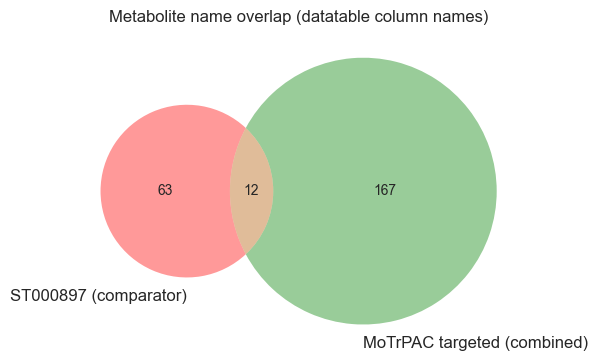

In [13]:
# Part 1: Identify metabolites shared across studies

# Query the Metabolomics Workbench RefMet service for a metabolite name
def refmet_match(name: str, timeout: int = 30):
    url = (
        f"{MW_BASE}/refmet/match/"
        f"{requests.utils.quote(str(name))}"
    )

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    return response.json()

# Cache RefMet results to avoid repeated API requests
_refmet_cache = {}

def refmet_match_cached(name: str, sleep_seconds: float = 0.0):
    if name in _refmet_cache:
        return _refmet_cache[name]

    try:
        result = refmet_match(name)

    except Exception as error:
        result = {
            "input_name": name,
            "error": str(error)
        }

    _refmet_cache[name] = result

    if sleep_seconds:
        time.sleep(sleep_seconds)

    return result

# Annotate metabolite column names using RefMet
def annotate_datatable_metabolites_with_refmet(
    datatable_path: str,
    n_max: int | None = None,
    sleep_seconds: float = 0.0
):
    datatable = pd.read_csv(
        datatable_path,
        sep="\t",
        low_memory=False
    )

    metabolite_columns = [
        column
        for column in datatable.columns
        if column not in ["Samples", "Class"]
    ]

    if n_max is not None:
        metabolite_columns = metabolite_columns[:n_max]

    rows = []

    for metabolite in metabolite_columns:
        response = refmet_match_cached(
            metabolite,
            sleep_seconds=sleep_seconds
        )

        rows.append({
            "input_name": metabolite,
            "refmet_name": response.get("refmet_name"),
            "refmet_id": response.get("refmet_id"),
            "formula": response.get("formula"),
            "exactmass": response.get("exactmass"),
            "super_class": response.get("super_class"),
            "main_class": response.get("main_class"),
            "sub_class": response.get("sub_class"),
            "error": response.get("error")
        })

    return pd.DataFrame(rows)

# Demonstrate RefMet annotation using the comparator study
comparator_datatable_path = os.path.join(
    DATA_DIR,
    "ST000897_AN001459_datatable.tsv"
)

refmet_annot_df = annotate_datatable_metabolites_with_refmet(
    comparator_datatable_path,
    n_max=50,
    sleep_seconds=0.0
)

# Confirm that required study metadata are available
assert "selected_heart_studies_df" in globals(), (
    "selected_heart_studies_df not found. "
    "Run the selected-study summary section first."
)

# Extract a study accession from a downloaded datatable filename
def parse_study_id(filename: str) -> str | None:
    match = re.match(
        r"(ST\d{6})_(AN\d{6})_datatable.tsv$",
        filename
    )

    return match.group(1) if match else None

# Map study accessions to targeted/untargeted metabolomics type
type_map = dict(
    zip(
        selected_heart_studies_df["study_id"].astype(str),
        selected_heart_studies_df["metabolomics_type"]
        .astype(str)
        .str.lower()
    )
)

# Collect metabolite names from the comparator and MoTrPAC datasets
comparator_metabolites = set()
motrpac_targeted_metabolites = set()
motrpac_untargeted_metabolites = set()

for path in glob.glob(
    os.path.join(
        DATA_DIR,
        "*_datatable.tsv"
    )
):
    filename = os.path.basename(path)
    study_id = parse_study_id(filename)

    if study_id is None:
        continue

    # Read only column names; no metabolite values are needed here
    header = pd.read_csv(
        path,
        sep="\t",
        nrows=0
    )

    metabolite_columns = [
        column
        for column in header.columns
        if column not in ["Samples", "Class"]
    ]

    if study_id == COMPARATOR_STUDY_ID:
        comparator_metabolites |= set(metabolite_columns)

    else:
        metabolomics_type = type_map.get(study_id)

        if metabolomics_type == "targeted":
            motrpac_targeted_metabolites |= set(metabolite_columns)

        elif metabolomics_type == "untargeted":
            motrpac_untargeted_metabolites |= set(metabolite_columns)

# Identify metabolites with matching column names across studies
shared_targeted = (
    comparator_metabolites
    .intersection(motrpac_targeted_metabolites)
)

shared_untargeted = (
    comparator_metabolites
    .intersection(motrpac_untargeted_metabolites)
)

# Report metabolite overlap
print(
    "Comparator metabolites:",
    len(comparator_metabolites)
)
print(
    "MoTrPAC targeted metabolites (combined):",
    len(motrpac_targeted_metabolites)
)
print(
    "Overlap vs targeted (shared names):",
    len(shared_targeted)
)
print(
    "Shared metabolite names (targeted):",
    sorted(shared_targeted)
)
print(
    "\nMoTrPAC untargeted metabolites (combined):",
    len(motrpac_untargeted_metabolites)
)
print(
    "Overlap vs untargeted (shared names):",
    len(shared_untargeted)
)

if len(shared_untargeted) == 0:
    print(
        "Shared metabolite names (untargeted): "
        "NONE (0 overlaps)"
    )
else:
    print(
        "Shared metabolite names (untargeted):",
        sorted(shared_untargeted)
    )

# Display the metabolite-name overlap between the comparator and combined MoTrPAC targeted datasets
plt.figure(figsize=(6, 6))

venn2(
    subsets=(
        len(
            comparator_metabolites
            - motrpac_targeted_metabolites
        ),
        len(
            motrpac_targeted_metabolites
            - comparator_metabolites
        ),
        len(shared_targeted)
    ),
    set_labels=(
        f"{COMPARATOR_STUDY_ID} (comparator)",
        "MoTrPAC targeted (combined)"
    )
)

plt.title(
    "Metabolite name overlap "
    "(datatable column names)"
)

plt.tight_layout()
plt.show()

Shared comparator vs MoTrPAC targeted metabolites: 12
Shared metabolite names: ['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']
Loaded RefMet cache: 12 entries


,input_name,refmet_name,refmet_id,formula,exactmass,super_class,main_class,sub_class,error
0,Alanine,Alanine,RM0135898,C3H7NO2,89.0477,Organic acids,Amino acids and peptides,Amino acids,NaN
1,Asparagine,Asparagine,RM0135724,C4H8N2O3,132.0535,Organic acids,Amino acids and peptides,Amino acids,NaN
2,Ethanolamine,Ethanolamine,RM0040238,C2H7NO,61.0528,Organic nitrogen compounds,Amines,"1,2-aminoalcohols",NaN
3,Glutamine,Glutamine,RM0012560,C5H10N2O3,146.0691,Organic acids,Amino acids and peptides,Amino acids,NaN
4,Glycine,Glycine,RM0135888,C2H5NO2,75.0320,Organic acids,Amino acids and peptides,Amino acids,NaN
5,Histidine,Histidine,RM0129894,C6H9N3O2,155.0695,Organic acids,Amino acids and peptides,Amino acids,NaN
6,Lysine,Lysine,RM0135903,C6H14N2O2,146.1055,Organic acids,Amino acids and peptides,Amino acids,NaN
7,Proline,Proline,RM0135899,C5H9NO2,115.0633,Organic acids,Amino acids and peptides,Amino acids,NaN
8,Serine,Serine,RM0032433,C3H7NO3,105.0426,Organic acids,Amino acids and peptides,Amino acids,NaN
9,Taurine,Taurine,RM0118223,C2H7NO3S,125.0147,Organic acids,Sulfonic acids,Sulfonic acids,NaN


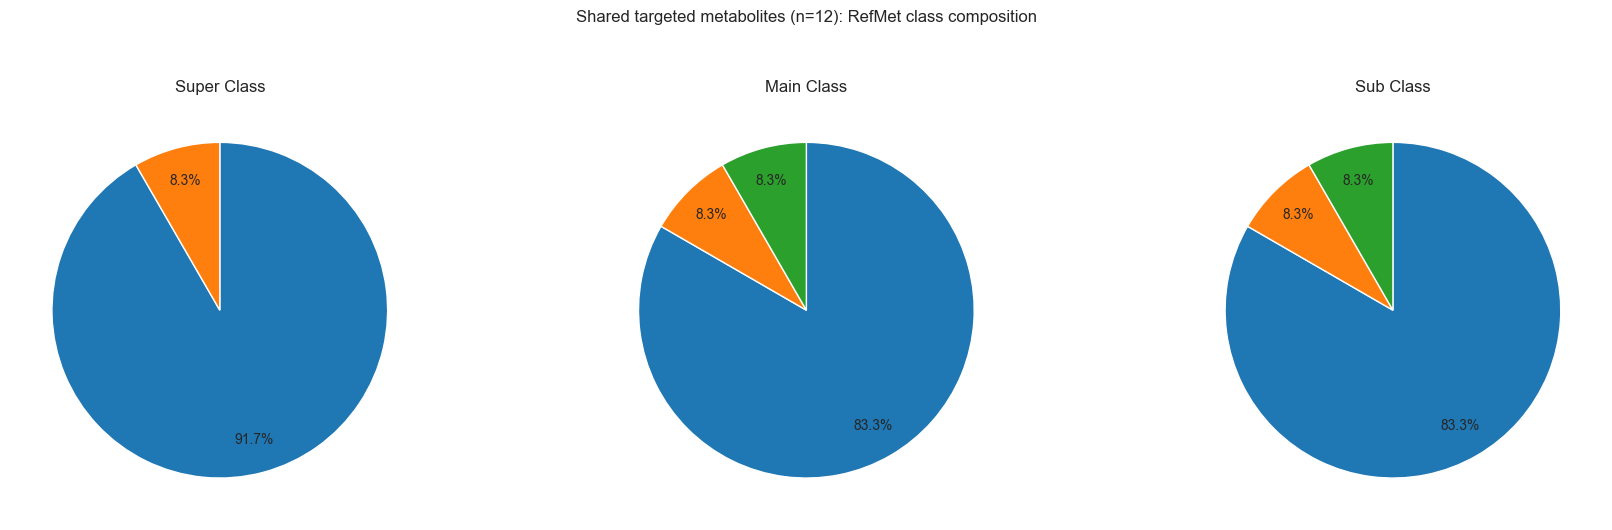


Legend for super class:
  1. Organic acids (n=11)
  2. Organic nitrogen compounds (n=1)

Legend for main class:
  1. Amino acids and peptides (n=10)
  2. Amines (n=1)
  3. Sulfonic acids (n=1)

Legend for sub class:
  1. Amino acids (n=10)
  2. 1,2-aminoalcohols (n=1)
  3. Sulfonic acids (n=1)


In [14]:
# Part 2: Examine RefMet class composition of shared metabolites

# Use the shared targeted metabolite names identified in Part 1
shared_metabolites = sorted(shared_targeted)

print(
    "Shared comparator vs MoTrPAC targeted metabolites:",
    len(shared_metabolites)
)

print(
    "Shared metabolite names:",
    shared_metabolites
)

# Persistent RefMet cache
CACHE_PATH = "./data/refmet_cache.csv"

CACHE_COLUMNS = [
    "input_name",
    "refmet_name",
    "refmet_id",
    "formula",
    "exactmass",
    "super_class",
    "main_class",
    "sub_class",
    "error"
]

# Load an existing RefMet cache if available
persistent_refmet_cache = {}

if os.path.exists(CACHE_PATH):
    cache_df = pd.read_csv(CACHE_PATH)

    for column in CACHE_COLUMNS:
        if column not in cache_df.columns:
            cache_df[column] = None

    cache_df = cache_df[CACHE_COLUMNS]

    persistent_refmet_cache = {
        row["input_name"]: row.to_dict()
        for _, row in cache_df.iterrows()
    }

    print(
        "Loaded RefMet cache:",
        len(persistent_refmet_cache),
        "entries"
    )

# Save RefMet results so they can be reused in later notebook runs
def save_refmet_cache():
    os.makedirs(
        os.path.dirname(CACHE_PATH) or ".",
        exist_ok=True
    )

    if not persistent_refmet_cache:
        return

    cache_df = pd.DataFrame(persistent_refmet_cache.values())

    for column in CACHE_COLUMNS:
        if column not in cache_df.columns:
            cache_df[column] = None

    cache_df[CACHE_COLUMNS].to_csv(
        CACHE_PATH,
        index=False
    )

# Query RefMet and return a standardized record
def refmet_match_record(name: str, timeout: int = 30) -> dict:
    result = refmet_match(
        name,
        timeout=timeout
    )

    return {
        "input_name": name,
        "refmet_name": result.get("refmet_name"),
        "refmet_id": result.get("refmet_id"),
        "formula": result.get("formula"),
        "exactmass": result.get("exactmass"),
        "super_class": result.get("super_class"),
        "main_class": result.get("main_class"),
        "sub_class": result.get("sub_class"),
        "error": None
    }

# Retrieve RefMet annotations, using the persistent cache when possible
def refmet_match_persistent(name: str) -> dict:
    if name in persistent_refmet_cache:
        return persistent_refmet_cache[name]

    try:
        record = refmet_match_record(name)

    except Exception as error:
        record = {
            column: None
            for column in CACHE_COLUMNS
        }

        record["input_name"] = name
        record["error"] = str(error)

    persistent_refmet_cache[name] = record

    return record

# Annotate all metabolites shared between the comparator and MoTrPAC targeted datasets
if shared_metabolites:
    refmet_shared_df = pd.DataFrame([
        refmet_match_persistent(metabolite)
        for metabolite in shared_metabolites
    ])

    save_refmet_cache()

    display(refmet_shared_df)

else:
    refmet_shared_df = pd.DataFrame(
        columns=CACHE_COLUMNS
    )

    print(
        "No shared targeted metabolites were found, "
        "so RefMet class composition cannot be calculated."
    )

# Plot RefMet class composition
def pie_on_ax(ax, counts: pd.Series, title: str) -> list[str]:
    counts = counts.fillna("Unmatched/Unknown")

    labels = (
        counts.index
        .astype(str)
        .tolist()
    )

    sizes = (
        counts.values
        .astype(float)
    )

    ax.pie(
        sizes,
        startangle=90,
        counterclock=False,
        labels=None,
        autopct=lambda percent: (
            f"{percent:.1f}%"
            if percent >= 5
            else ""
        ),
        pctdistance=0.8
    )

    ax.set_title(
        title.replace("_", " ").title()
    )

    legend_lines = [
        f"{i + 1}. {labels[i]} "
        f"(n={int(sizes[i])})"
        for i in range(len(labels))
    ]

    return legend_lines

# Visualize RefMet super-, main-, and sub-class composition
classification_levels = [
    "super_class",
    "main_class",
    "sub_class"
]

if not refmet_shared_df.empty:
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    fig.suptitle(
        f"Shared targeted metabolites "
        f"(n={len(shared_metabolites)}): "
        "RefMet class composition",
        y=1.05
    )

    legends = {}

    for ax, classification_level in zip(
        axes,
        classification_levels
    ):
        counts = (
            refmet_shared_df[
                classification_level
            ]
            .fillna("Unmatched/Unknown")
            .value_counts()
        )

        legends[classification_level] = (
            pie_on_ax(
                ax,
                counts,
                title=classification_level
            )
        )

    fig.tight_layout()

    # Display the results and figure legends
    display(fig)
    plt.close(fig)

    for classification_level in classification_levels:
        print(
            f"\nLegend for "
            f"{classification_level.replace('_', ' ')}:"
        )

        for line in legends[
            classification_level
        ]:
            print("  " + line)

Auto-selected overlapping metabolites:
['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']


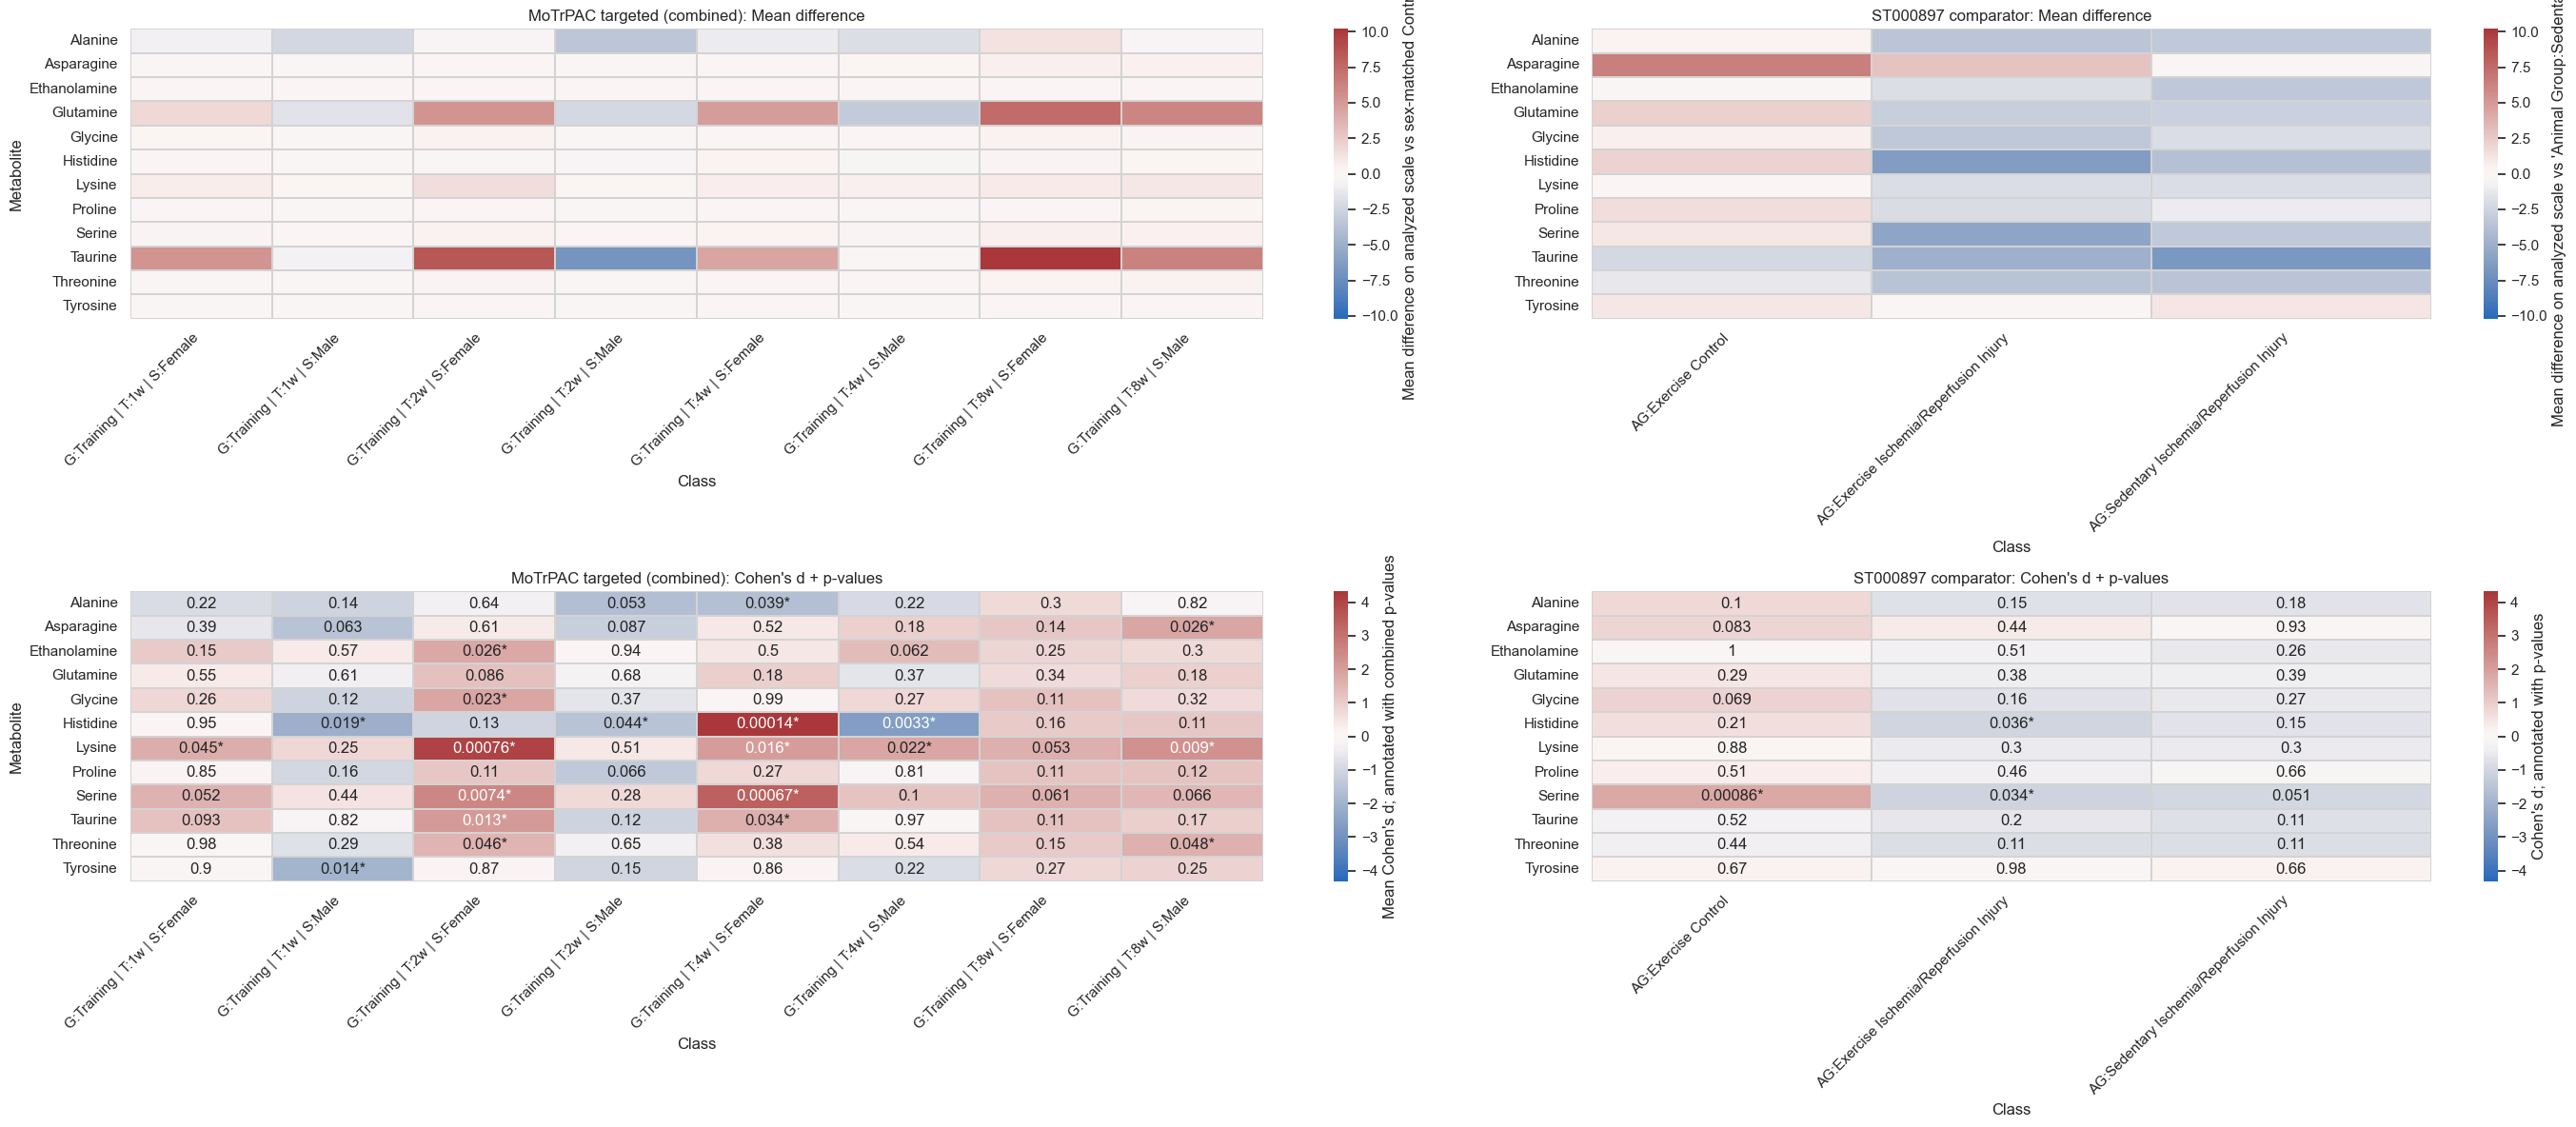


How to interpret the heatmaps:
Top row — Fold change mean difference: Color represents the difference between the experimental-group mean and its within-study control. Positive values indicate higher metabolite abundance relative to control, while negative values indicate lower abundance.

Bottom row — Cohen's d effect size: Color represents standardized effect size. Positive and negative values indicate the direction of the group difference.
Numbers inside the Cohen's d heatmaps are p-values.

Class-label abbreviations: G = Group; AG = Animal Group; T = Timepoint; S = Sex.

Note: The upper heatmaps show mean differences on the analyzed scale and should not automatically be interpreted as fold changes unless the underlying scale supports that interpretation.

Heatmap data saved to: /Users/ericleslie/Projects/MoTrPAC_x_MetabolomicsWorkbench/outputs


In [15]:
# Part 3: Transform and statistically analyze shared metabolites

OVERLAP_FEATURES = []
COMPARATOR_BASELINE_CLASS = "Animal Group:Sedentary Control"
MOTRPAC_CONTROL_PREFIX = "Group:Control"
MOTRPAC_TIMEPOINT_SUBSTR = "Timepoint:8 weeks of training or control time"

EXCLUDE_QC = True
ZERO_AS_MISSING = False
ANNOTATE_WITH = "p"  # "p" or "q"
PVAL_FORMAT = "{:.2g}"
SIGNIFICANCE_THRESHOLD = 0.05
DROP_BASELINE_COLUMNS = True

# Map each Study ID / Analysis ID to its earlier transformation recommendation
transform_map = dict(zip(
    norm_check_df["study_id"].astype(str) + "||" + norm_check_df["analysis_id"].astype(str),
    norm_check_df["recommended_transform"].astype(str)
))

def apply_transform(series: pd.Series, recommendation: str, zero_as_missing: bool = False) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    if zero_as_missing:
        values = values.mask(values == 0)

    recommendation = (recommendation or "").lower()
    if "log2(x + 1)" in recommendation:
        values = values.mask(values < 0)
        return np.log2(values + 1)

    return values

def get_feature_columns_from_file(path: str) -> list[str]:
    header = pd.read_csv(path, sep="\t", nrows=0)
    return [column for column in header.columns if column not in ["Samples", "Class"]]

def build_motrpac_baseline_map(class_levels) -> dict:
    levels = [str(level) for level in class_levels]
    if EXCLUDE_QC:
        levels = [level for level in levels if "Group:QC-" not in level]

    controls = [
        level for level in levels
        if MOTRPAC_CONTROL_PREFIX in level and MOTRPAC_TIMEPOINT_SUBSTR in level
    ]

    control_by_sex = {}
    for control in controls:
        if "Sex:Female" in control:
            control_by_sex["Female"] = control
        if "Sex:Male" in control:
            control_by_sex["Male"] = control

    baseline_for = {}
    for level in levels:
        if "Sex:Female" in level and "Female" in control_by_sex:
            baseline_for[level] = control_by_sex["Female"]
        elif "Sex:Male" in level and "Male" in control_by_sex:
            baseline_for[level] = control_by_sex["Male"]
        else:
            baseline_for[level] = None

    return baseline_for

def cohen_d(group_values, baseline_values) -> float:
    group_values = np.asarray(group_values, dtype=float)
    baseline_values = np.asarray(baseline_values, dtype=float)
    n_group, n_baseline = len(group_values), len(baseline_values)

    if n_group < 2 or n_baseline < 2:
        return np.nan

    sd_group = np.nanstd(group_values, ddof=1)
    sd_baseline = np.nanstd(baseline_values, ddof=1)

    pooled_sd = np.sqrt(
        ((n_group - 1) * sd_group**2 + (n_baseline - 1) * sd_baseline**2) /
        (n_group + n_baseline - 2)
    )

    if not np.isfinite(pooled_sd) or pooled_sd == 0:
        return np.nan

    return (np.nanmean(group_values) - np.nanmean(baseline_values)) / pooled_sd

def fisher_combine(p_values) -> float:
    valid = np.array(
        [p for p in p_values if np.isfinite(p) and 0 < p <= 1],
        dtype=float
    )
    return np.nan if valid.size == 0 else float(combine_pvalues(valid, method="fisher")[1])

def add_q_values(dataframe: pd.DataFrame, p_column: str = "pval_comb") -> pd.DataFrame:
    p_values = dataframe[p_column].to_numpy()
    valid = np.isfinite(p_values)
    q_values = np.full_like(p_values, np.nan, dtype=float)

    if valid.sum() > 0:
        q_values[valid] = multipletests(p_values[valid], method="fdr_bh")[1]

    result = dataframe.copy()
    result["qval"] = q_values
    return result

def shorten_labels(labels) -> list[str]:
    shortened = []
    for label in labels:
        label = str(label)
        label = label.replace("Animal Group:", "AG:")
        label = label.replace("Group:", "G:")
        label = label.replace("Timepoint:", "T:")
        label = label.replace(" weeks of training or control time", "w")
        label = label.replace(" week of training or control time", "w")
        label = label.replace(" weeks of training", "w")
        label = label.replace("Sex:", "S:")
        shortened.append(label)
    return shortened

# Locate downloaded datatables and use shared targeted metabolites from Part 1
paths = sorted(glob.glob(os.path.join(DATA_DIR, "*_datatable.tsv")))
if not paths:
    raise FileNotFoundError(f"No datatables found in {DATA_DIR}")

shared = sorted(shared_targeted)
if not shared:
    raise ValueError("No metabolites are shared between the comparator and MoTrPAC targeted datasets.")

if not OVERLAP_FEATURES:
    OVERLAP_FEATURES = shared[:12]
    print("Auto-selected overlapping metabolites:")
    print(OVERLAP_FEATURES)

# Calculate group-vs-baseline statistics
motrpac_rows, comparator_rows = [], []

for path in paths:
    study_id, analysis_id = parse_study_analysis(os.path.basename(path))
    if study_id is None:
        continue

    is_comparator = study_id == COMPARATOR_STUDY_ID
    is_targeted_motrpac = type_map.get(study_id) == "targeted"
    if not is_comparator and not is_targeted_motrpac:
        continue

    datatable = pd.read_csv(path, sep="\t", low_memory=False)
    features_here = [feature for feature in OVERLAP_FEATURES if feature in datatable.columns]
    if not features_here:
        continue

    if is_targeted_motrpac and EXCLUDE_QC:
        datatable = datatable[
            ~datatable["Class"].astype(str).str.contains("Group:QC-", na=False)
        ].copy()

    transformation = transform_map.get(f"{study_id}||{analysis_id}", "")
    analysis_df = datatable[["Samples", "Class"] + features_here].copy()

    for feature in features_here:
        analysis_df[feature] = apply_transform(
            analysis_df[feature], transformation, zero_as_missing=ZERO_AS_MISSING
        )

    class_levels = analysis_df["Class"].astype(str).unique().tolist()

    if is_comparator:
        baseline_df = analysis_df[
            analysis_df["Class"].astype(str) == COMPARATOR_BASELINE_CLASS
        ]

        for group in class_levels:
            group_df = analysis_df[analysis_df["Class"].astype(str) == group]

            for feature in features_here:
                a = group_df[feature].dropna().values
                b = baseline_df[feature].dropna().values

                mean_difference = (
                    float(np.nanmean(a) - np.nanmean(b))
                    if len(a) and len(b) else np.nan
                )
                effect_size = float(cohen_d(a, b))
                p_value = (
                    float(ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue)
                    if len(a) >= 2 and len(b) >= 2 else np.nan
                )

                comparator_rows.append(
                    (study_id, analysis_id, group, feature, mean_difference, effect_size, p_value)
                )

    if is_targeted_motrpac:
        baseline_map = build_motrpac_baseline_map(class_levels)

        for group in class_levels:
            baseline = baseline_map.get(group)
            if baseline is None:
                continue

            group_df = analysis_df[analysis_df["Class"].astype(str) == group]
            baseline_df = analysis_df[analysis_df["Class"].astype(str) == baseline]

            for feature in features_here:
                a = group_df[feature].dropna().values
                b = baseline_df[feature].dropna().values

                mean_difference = (
                    float(np.nanmean(a) - np.nanmean(b))
                    if len(a) and len(b) else np.nan
                )
                effect_size = float(cohen_d(a, b))
                p_value = (
                    float(ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue)
                    if len(a) >= 2 and len(b) >= 2 else np.nan
                )

                motrpac_rows.append(
                    (study_id, analysis_id, group, feature, mean_difference, effect_size, p_value)
                )

# Assemble result tables
columns = ["study_id", "analysis_id", "group", "feature", "fc", "d", "pval"]
motrpac_df = pd.DataFrame(motrpac_rows, columns=columns)
comparator_df = pd.DataFrame(comparator_rows, columns=columns)

motrpac_meta = (
    motrpac_df.groupby(["group", "feature"], as_index=False)
    .agg(fc=("fc", "mean"), d=("d", "mean"), pval_comb=("pval", fisher_combine))
)
motrpac_meta = add_q_values(motrpac_meta)

comparator_meta = (
    comparator_df.groupby(["group", "feature"], as_index=False)
    .agg(fc=("fc", "mean"), d=("d", "mean"), pval_comb=("pval", fisher_combine))
)
comparator_meta = add_q_values(comparator_meta)

# Convert results to heatmap matrices
p_column = "qval" if ANNOTATE_WITH == "q" else "pval_comb"

targeted_fc = motrpac_meta.pivot(index="feature", columns="group", values="fc").reindex(OVERLAP_FEATURES)
targeted_d = motrpac_meta.pivot(index="feature", columns="group", values="d").reindex(OVERLAP_FEATURES)
targeted_p = motrpac_meta.pivot(index="feature", columns="group", values=p_column).reindex(OVERLAP_FEATURES)

comparator_fc = comparator_meta.pivot(index="feature", columns="group", values="fc").reindex(OVERLAP_FEATURES)
comparator_d = comparator_meta.pivot(index="feature", columns="group", values="d").reindex(OVERLAP_FEATURES)
comparator_p = comparator_meta.pivot(index="feature", columns="group", values=p_column).reindex(OVERLAP_FEATURES)

# Remove baseline-vs-baseline columns
baseline_columns_motrpac = [
    c for c in targeted_fc.columns
    if MOTRPAC_CONTROL_PREFIX in str(c) and MOTRPAC_TIMEPOINT_SUBSTR in str(c)
]
baseline_columns_comparator = (
    [COMPARATOR_BASELINE_CLASS]
    if COMPARATOR_BASELINE_CLASS in comparator_fc.columns else []
)

if DROP_BASELINE_COLUMNS:
    for matrix in [targeted_fc, targeted_d, targeted_p]:
        matrix.drop(columns=baseline_columns_motrpac, errors="ignore", inplace=True)

    for matrix in [comparator_fc, comparator_d, comparator_p]:
        matrix.drop(columns=baseline_columns_comparator, errors="ignore", inplace=True)

# Display p/q-values and mark values < 0.05 with an asterisk
def format_significance(value):
    if not np.isfinite(value):
        return ""
    formatted = PVAL_FORMAT.format(value)
    return f"{formatted}*" if value < SIGNIFICANCE_THRESHOLD else formatted

targeted_annotations = targeted_p.map(format_significance)
comparator_annotations = comparator_p.map(format_significance)

# Use symmetric color scales centered on zero
def symmetric_vmax(*matrices):
    values = np.concatenate([matrix.to_numpy().ravel() for matrix in matrices])
    values = values[np.isfinite(values)]
    maximum = float(np.max(np.abs(values))) if values.size else 1.0
    return max(maximum, 0.5)

fc_vmax = symmetric_vmax(targeted_fc, comparator_fc)
d_vmax = symmetric_vmax(targeted_d, comparator_d)

# Plot heatmaps
sns.set(context="notebook", style="white")
fig, axes = plt.subplots(2, 2, figsize=(28, 12), gridspec_kw={"width_ratios": [1.35, 1]})

sns.heatmap(
    targeted_fc, ax=axes[0, 0], cmap="vlag", center=0, vmin=-fc_vmax, vmax=fc_vmax,
    linewidths=0.3, linecolor="lightgrey",
    cbar_kws={"label": "Mean difference on analyzed scale vs sex-matched Control@8w"}
)
axes[0, 0].set_title("MoTrPAC targeted (combined): Mean difference")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Metabolite")
axes[0, 0].set_xticklabels(shorten_labels(targeted_fc.columns), rotation=45, ha="right")

sns.heatmap(
    comparator_fc, ax=axes[0, 1], cmap="vlag", center=0, vmin=-fc_vmax, vmax=fc_vmax,
    linewidths=0.3, linecolor="lightgrey",
    cbar_kws={"label": f"Mean difference on analyzed scale vs '{COMPARATOR_BASELINE_CLASS}'"}
)
axes[0, 1].set_title(f"{COMPARATOR_STUDY_ID} comparator: Mean difference")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xticklabels(shorten_labels(comparator_fc.columns), rotation=45, ha="right")

sns.heatmap(
    targeted_d, ax=axes[1, 0], cmap="vlag", center=0, vmin=-d_vmax, vmax=d_vmax,
    annot=targeted_annotations, fmt="", linewidths=0.3, linecolor="lightgrey",
    cbar_kws={"label": f"Mean Cohen's d; annotated with combined {ANNOTATE_WITH}-values"}
)
axes[1, 0].set_title(f"MoTrPAC targeted (combined): Cohen's d + {ANNOTATE_WITH}-values")
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Metabolite")
axes[1, 0].set_xticklabels(shorten_labels(targeted_d.columns), rotation=45, ha="right")

sns.heatmap(
    comparator_d, ax=axes[1, 1], cmap="vlag", center=0, vmin=-d_vmax, vmax=d_vmax,
    annot=comparator_annotations, fmt="", linewidths=0.3, linecolor="lightgrey",
    cbar_kws={"label": f"Cohen's d; annotated with {ANNOTATE_WITH}-values"}
)
axes[1, 1].set_title(f"{COMPARATOR_STUDY_ID} comparator: Cohen's d + {ANNOTATE_WITH}-values")
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xticklabels(shorten_labels(comparator_d.columns), rotation=45, ha="right")

fig.tight_layout()
display(fig)
plt.close(fig)

print("\nHow to interpret the heatmaps:")
print("Top row — Fold change mean difference: Color represents the difference between the experimental-group mean "
    "and its within-study control. Positive values indicate higher metabolite "
    "abundance relative to control, while negative values indicate lower abundance.")

print("\nBottom row — Cohen's d effect size: Color represents standardized effect size. Positive and negative values "
    "indicate the direction of the group difference.")

if ANNOTATE_WITH == "q":
    print("Numbers inside the Cohen's d heatmaps are Benjamini-Hochberg FDR-adjusted q-values.")
else:
    print("Numbers inside the Cohen's d heatmaps are p-values.")

print("\nClass-label abbreviations: G = Group; AG = Animal Group; T = Timepoint; S = Sex.")

print("\nNote: The upper heatmaps show mean differences on the analyzed scale and should not "
    "automatically be interpreted as fold changes unless the underlying scale supports that interpretation.")

# Save heatmap data
targeted_fc.to_csv(os.path.join(OUTDIR, "heatmap_motrpac_targeted_fc.tsv"), sep="\t", na_rep="NA")
comparator_fc.to_csv(os.path.join(OUTDIR, "heatmap_comparator_fc.tsv"), sep="\t", na_rep="NA")
targeted_d.to_csv(os.path.join(OUTDIR, "heatmap_motrpac_targeted_cohens_d.tsv"), sep="\t", na_rep="NA")
comparator_d.to_csv(os.path.join(OUTDIR, "heatmap_comparator_cohens_d.tsv"), sep="\t", na_rep="NA")
targeted_p.to_csv(os.path.join(OUTDIR, f"heatmap_motrpac_targeted_{ANNOTATE_WITH}vals.tsv"), sep="\t", na_rep="NA")
comparator_p.to_csv(os.path.join(OUTDIR, f"heatmap_comparator_{ANNOTATE_WITH}vals.tsv"), sep="\t", na_rep="NA")

print("\nHeatmap data saved to:", os.path.abspath(OUTDIR))

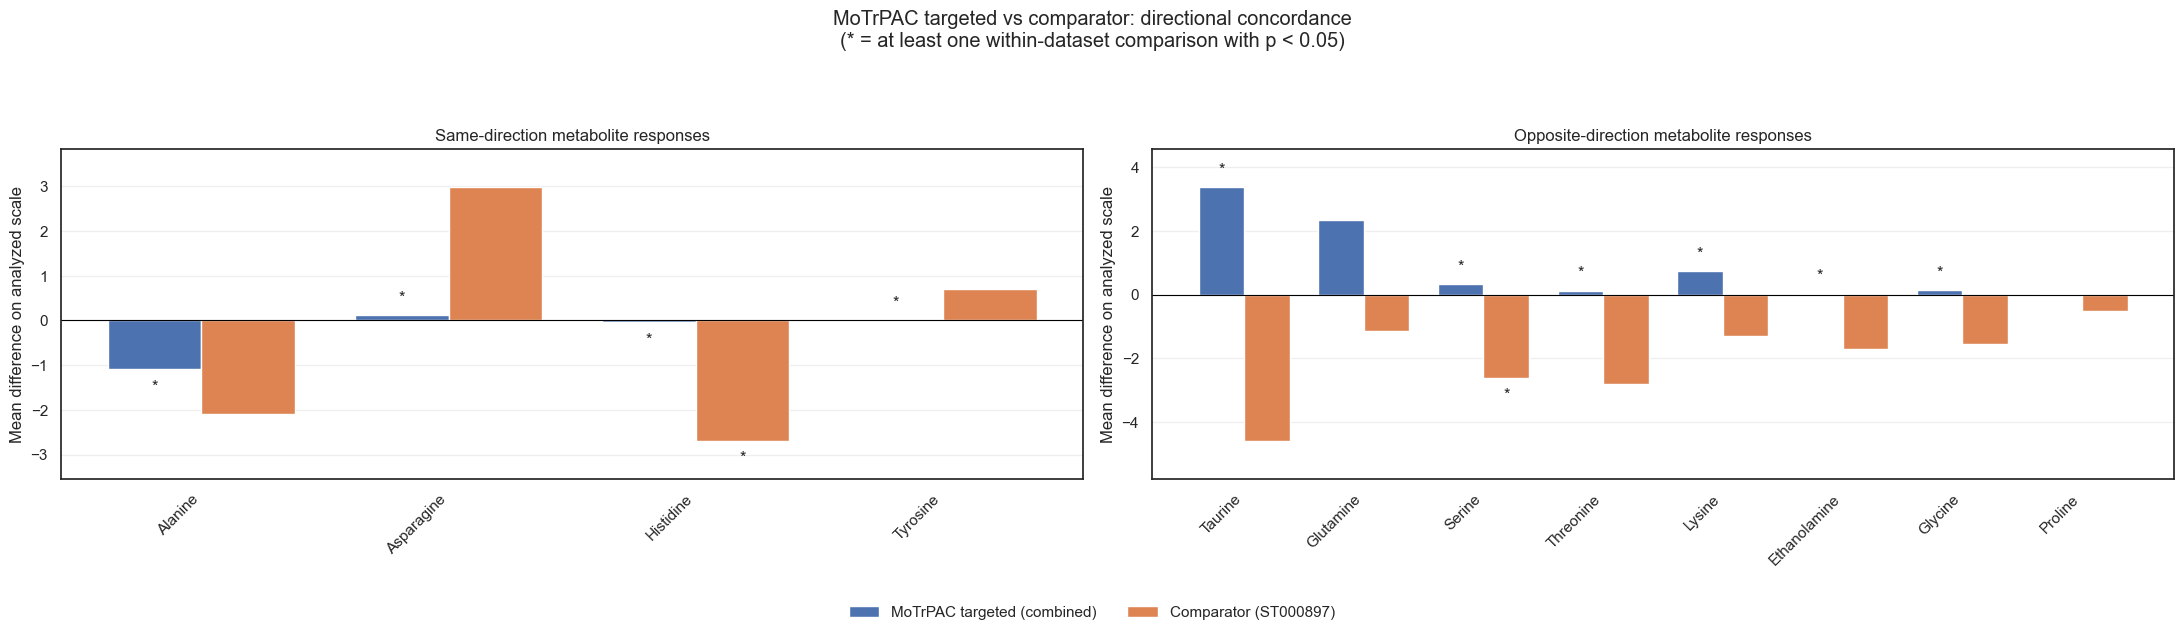


How to interpret the bar plots:
Same-direction metabolites have fold changes in the same direction (both are increased metabolite abundance in MoTrPAC and the comparator, or both are decreased).
An asterisk (*) indicates that at least one group comparison for that metabolite has p < 0.05; it does not mean every group comparison is significant.


In [16]:
# Part 4: Evaluate directional concordance across studies

DIRECTION_ALPHA = SIGNIFICANCE_THRESHOLD
AGG = "mean"
SORT_BY = "abs_mean"
DROP_ZERO_DIR = True

# Confirm required matrices from Part 3 are available
for name in ["targeted_fc", "comparator_fc", "targeted_p", "comparator_p"]:
    assert name in globals(), f"Required object '{name}' not found. Run Part 3 first."

# Retain metabolites present in both MoTrPAC and comparator result matrices
metabolites = sorted(set(targeted_fc.index.astype(str)) & set(comparator_fc.index.astype(str)))
targeted_fc2 = targeted_fc.loc[metabolites].copy()
comparator_fc2 = comparator_fc.loc[metabolites].copy()
targeted_p2 = targeted_p.loc[metabolites].copy()
comparator_p2 = comparator_p.loc[metabolites].copy()

def collapse_effect_and_significance(effect_matrix: pd.DataFrame, p_matrix: pd.DataFrame, agg: str):
    effects = effect_matrix.apply(pd.to_numeric, errors="coerce")
    p_values = p_matrix.apply(pd.to_numeric, errors="coerce")

    # A metabolite is flagged if any displayed group comparison passes the threshold
    significant = (p_values < DIRECTION_ALPHA).any(axis=1)

    if agg == "mean":
        collapsed_effect = effects.mean(axis=1, skipna=True)
    elif agg == "max_abs":
        max_columns = effects.abs().idxmax(axis=1)
        collapsed_effect = pd.Series(
            [effects.loc[m, max_columns[m]] if pd.notna(max_columns[m]) else np.nan for m in effects.index],
            index=effects.index
        )
    else:
        raise ValueError("Unknown AGG: " + agg)

    return collapsed_effect, significant

targeted_effect, targeted_sig = collapse_effect_and_significance(targeted_fc2, targeted_p2, AGG)
comparator_effect, comparator_sig = collapse_effect_and_significance(comparator_fc2, comparator_p2, AGG)

concordance_df = pd.DataFrame({
    "metabolite": metabolites,
    "effect_motrpac": targeted_effect.values,
    "effect_comparator": comparator_effect.values,
    "sig_motrpac": targeted_sig.values,
    "sig_comparator": comparator_sig.values
}).set_index("metabolite").dropna(subset=["effect_motrpac", "effect_comparator"])

def direction(value):
    if value > 0:
        return 1
    if value < 0:
        return -1
    return 0

concordance_df["dir_motrpac"] = concordance_df["effect_motrpac"].apply(direction)
concordance_df["dir_comparator"] = concordance_df["effect_comparator"].apply(direction)

if DROP_ZERO_DIR:
    concordance_df = concordance_df[
        (concordance_df["dir_motrpac"] != 0) &
        (concordance_df["dir_comparator"] != 0)
    ]

same_df = concordance_df[
    concordance_df["dir_motrpac"] == concordance_df["dir_comparator"]
].copy()

opposite_df = concordance_df[
    concordance_df["dir_motrpac"] != concordance_df["dir_comparator"]
].copy()

# Rank metabolites by overall magnitude of response
if SORT_BY == "abs_mean":
    same_df["sort_key"] = same_df[["effect_motrpac", "effect_comparator"]].abs().mean(axis=1)
    opposite_df["sort_key"] = opposite_df[["effect_motrpac", "effect_comparator"]].abs().mean(axis=1)
elif SORT_BY == "abs_diff":
    same_df["sort_key"] = (same_df["effect_motrpac"] - same_df["effect_comparator"]).abs()
    opposite_df["sort_key"] = (opposite_df["effect_motrpac"] - opposite_df["effect_comparator"]).abs()
else:
    raise ValueError("Unknown SORT_BY: " + SORT_BY)

same_df = same_df.sort_values("sort_key", ascending=False)
opposite_df = opposite_df.sort_values("sort_key", ascending=False)

def plot_two_barsets(ax, subset, title):
    metabolites = subset.index.tolist()
    x = np.arange(len(metabolites))
    width = 0.38

    y_motrpac = subset["effect_motrpac"].values
    y_comparator = subset["effect_comparator"].values

    bars_motrpac = ax.bar(x - width / 2, y_motrpac, width=width, label="MoTrPAC targeted (combined)")
    bars_comparator = ax.bar(x + width / 2, y_comparator, width=width, label=f"Comparator ({COMPARATOR_STUDY_ID})")

    ymin = np.nanmin(np.concatenate([y_motrpac, y_comparator])) if metabolites else -1
    ymax = np.nanmax(np.concatenate([y_motrpac, y_comparator])) if metabolites else 1
    padding = 0.15 * (ymax - ymin if ymax > ymin else 1)
    ax.set_ylim(ymin - padding, ymax + padding)

    def add_stars(bars, significance_flags):
        offset = 0.03 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        for bar, significant in zip(bars, significance_flags):
            if not significant:
                continue
            height = bar.get_height()
            x_position = bar.get_x() + bar.get_width() / 2
            y_position = height + offset if height >= 0 else height - offset
            ax.text(x_position, y_position, "*", ha="center",
                    va="bottom" if height >= 0 else "top", fontsize=12)

    add_stars(bars_motrpac, subset["sig_motrpac"].values)
    add_stars(bars_comparator, subset["sig_comparator"].values)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metabolites, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Mean difference on analyzed scale")
    ax.grid(axis="y", alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))

if same_df.empty:
    axes[0].text(0.5, 0.5, "No same-direction metabolites\n(after filtering)", ha="center", va="center")
    axes[0].set_axis_off()
else:
    plot_two_barsets(axes[0], same_df, "Same-direction metabolite responses")

if opposite_df.empty:
    axes[1].text(0.5, 0.5, "No opposite-direction metabolites\n(after filtering)", ha="center", va="center")
    axes[1].set_axis_off()
else:
    plot_two_barsets(axes[1], opposite_df, "Opposite-direction metabolite responses")

stat_label = "q" if ANNOTATE_WITH == "q" else "p"
fig.suptitle(
    f"MoTrPAC targeted vs comparator: directional concordance\n"
    f"(* = at least one within-dataset comparison with {stat_label} < {DIRECTION_ALPHA})",
    y=1.02
)

# Obtain legend from whichever panel contains data
legend_ax = axes[0] if not same_df.empty else axes[1]
handles, labels = legend_ax.get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.06, 1, 0.95])
display(fig)
plt.close(fig)

print("\nHow to interpret the bar plots:")
print("Same-direction metabolites have fold changes in the same direction (both are increased metabolite abundance in MoTrPAC and the comparator, or both are decreased).")
print(
    f"An asterisk (*) indicates that at least one group comparison for that metabolite has "
    f"{stat_label} < {DIRECTION_ALPHA}; it does not mean every group comparison is significant.")

In [17]:
# Part 5: Compare results interactively

INTERACTIVE_ALPHA = SIGNIFICANCE_THRESHOLD
SUMMARY_AGG = "mean"
TOP_K_CLASSES = None

for name in ["targeted_fc", "targeted_p", "comparator_fc", "comparator_p"]:
    assert name in globals(), f"Missing required object: {name}. Run Part 3 first."

def direction(value):
    if value > 0:
        return 1
    if value < 0:
        return -1
    return 0

def summarize_effect(effect_matrix, agg="mean"):
    effects = effect_matrix.apply(pd.to_numeric, errors="coerce")

    if agg == "mean":
        return effects.mean(axis=1, skipna=True)

    if agg == "max_abs":
        max_columns = effects.abs().idxmax(axis=1)
        return pd.Series(
            [effects.loc[m, max_columns[m]] if pd.notna(max_columns[m]) else np.nan for m in effects.index],
            index=effects.index
        )

    raise ValueError("Unknown aggregation method: " + agg)

# Determine same- and opposite-direction metabolites
common_metabolites = sorted(
    set(targeted_fc.index.astype(str)) & set(comparator_fc.index.astype(str))
)

motrpac_summary = summarize_effect(targeted_fc.loc[common_metabolites], SUMMARY_AGG)
comparator_summary = summarize_effect(comparator_fc.loc[common_metabolites], SUMMARY_AGG)

direction_summary = pd.DataFrame({
    "effect_motrpac": motrpac_summary,
    "effect_comparator": comparator_summary
}).dropna()

direction_summary["dir_motrpac"] = direction_summary["effect_motrpac"].apply(direction)
direction_summary["dir_comparator"] = direction_summary["effect_comparator"].apply(direction)

direction_summary = direction_summary[
    (direction_summary["dir_motrpac"] != 0) &
    (direction_summary["dir_comparator"] != 0)
]

same_metabolites = direction_summary[
    direction_summary["dir_motrpac"] == direction_summary["dir_comparator"]
].index.tolist()

opposite_metabolites = direction_summary[
    direction_summary["dir_motrpac"] != direction_summary["dir_comparator"]
].index.tolist()

# Convert heatmap matrices to long format for plotting
def make_long_within(effect_matrix, p_matrix, metabolites, source_name):
    effects = effect_matrix.loc[metabolites].apply(pd.to_numeric, errors="coerce")
    p_values = p_matrix.loc[metabolites].apply(pd.to_numeric, errors="coerce")

    effect_long = effects.stack(future_stack=True).reset_index()
    p_long = p_values.stack(future_stack=True).reset_index()

    effect_long.columns = ["metabolite", "class", "effect"]
    p_long.columns = ["metabolite", "class", "stat_value"]

    long_df = effect_long.merge(p_long, on=["metabolite", "class"], how="left")
    long_df["effect"] = pd.to_numeric(long_df["effect"], errors="coerce")
    long_df["stat_value"] = pd.to_numeric(long_df["stat_value"], errors="coerce")
    long_df = long_df[np.isfinite(long_df["effect"])].copy()

    long_df["significant"] = (
        np.isfinite(long_df["stat_value"]) &
        (long_df["stat_value"] < INTERACTIVE_ALPHA)
    )
    long_df["source"] = source_name

    if TOP_K_CLASSES is not None:
        long_df["abs_effect"] = long_df["effect"].abs()
        long_df = (
            long_df.sort_values(["metabolite", "abs_effect"], ascending=[True, False])
            .groupby("metabolite", as_index=False)
            .head(TOP_K_CLASSES)
            .drop(columns="abs_effect")
        )

    return long_df

same_long = pd.concat([
    make_long_within(targeted_fc, targeted_p, same_metabolites, "MoTrPAC"),
    make_long_within(comparator_fc, comparator_p, same_metabolites, "Comparator")
], ignore_index=True)

opposite_long = pd.concat([
    make_long_within(targeted_fc, targeted_p, opposite_metabolites, "MoTrPAC"),
    make_long_within(comparator_fc, comparator_p, opposite_metabolites, "Comparator")
], ignore_index=True)

# Build interactive grouped-bar plots
def interactive_within_plot(long_df, title):
    data = long_df.copy()

    stat_label = "q-value" if ANNOTATE_WITH == "q" else "p-value"
    data["significance"] = np.where(data["significant"], "*", "")
    data["stat_display"] = data["stat_value"].map(
        lambda x: "NA" if not np.isfinite(x) else f"{x:.2g}"
    )

    fig = px.bar(
        data,
        x="metabolite",
        y="effect",
        color="source",
        barmode="group",
        custom_data=["class", "stat_display", "significance"],
        title=title,
        labels={
            "metabolite": "Metabolite",
            "effect": "Mean difference on analyzed scale",
            "source": "Source"
        }
    )

    fig.update_traces(
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Source: %{fullData.name}<br>"
            "Class: %{customdata[0]}<br>"
            "Mean difference: %{y:.3g}<br>"
            f"{stat_label}: %{{customdata[1]}}%{{customdata[2]}}"
            "<extra></extra>"
        )
    )

    fig.update_layout(
        xaxis_title="Metabolite",
        yaxis_title="Mean difference on analyzed scale",
        legend_title="Source",
        bargap=0.25
    )

    fig.add_hline(y=0, line_width=1, line_color="black")
    return fig

fig_same = interactive_within_plot(
    same_long,
    "Same-direction metabolite responses — hover to view study-group details"
)

fig_opposite = interactive_within_plot(
    opposite_long,
    "Opposite-direction metabolite responses — hover to view study-group details"
)

fig_same.show()
fig_opposite.show()

print("\nHow to interpret the interactive plots:")
print("Each bar represents a within-study group comparison for a shared metabolite. "
    "Hover over a bar to view the study group, mean difference, and statistical value.")
print(
    f"An asterisk (*) beside the displayed {'q-value' if ANNOTATE_WITH == 'q' else 'p-value'} "
    f"indicates a value < {INTERACTIVE_ALPHA}."
)
print("Positive values indicate higher abundance relative to the corresponding within-study control; "
    "negative values indicate lower abundance.")
print("Interpretation note: it appears the comparator study group 'Animal Group: Sedentary Ischemia/Reperfusion Injury' had the lowest abundance for all opposite-direction metabolites.")


How to interpret the interactive plots:
Each bar represents a within-study group comparison for a shared metabolite. Hover over a bar to view the study group, mean difference, and statistical value.
An asterisk (*) beside the displayed p-value indicates a value < 0.05.
Positive values indicate higher abundance relative to the corresponding within-study control; negative values indicate lower abundance.
Interpretation note: it appears the comparator study group 'Animal Group: Sedentary Ischemia/Reperfusion Injury' had the lowest abundance for all opposite-direction metabolites.


---

## Learning Assessments (Learning Objective 3)

**Q1. Why might matching metabolite column names not be sufficient to determine whether the same metabolite is present across studies?**

A. Column names are always standardized by RefMet before being stored.  
B. Different laboratories or analytical platforms may use different names for the same metabolite or metabolite form.  
C. Column names only represent sample IDs, not metabolites.  
D. Matching names guarantee that the metabolite is chemically identical and measured comparably across studies.

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: B**

- **A (Incorrect):** Metabolomics Workbench datatables are not guaranteed to use RefMet-standardized metabolite names.
- **B (Correct):** Different studies may use alternative names, abbreviations, or descriptions for the same metabolite. Cross-study comparison therefore benefits from standardized identifiers such as RefMet names or IDs, together with information about the analytical method.
- **C (Incorrect):** In these datatables, `Samples` contains sample identifiers, while the remaining feature columns generally represent measured metabolites or metabolite features.
- **D (Incorrect):** Matching names alone do not guarantee identical chemical identity, analytical measurement, or quantitative comparability across studies.

</details>

**Q2. In the directional concordance analysis, how was an “opposite-direction” metabolite identified?**

A. The summarized mean differences had opposite signs in the MoTrPAC and comparator datasets.  
B. The metabolite had different amounts of missing data between studies.  
C. The metabolite was statistically significant in one study but not the other.  
D. The Cohen's *d* values differed in magnitude between studies.

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** A metabolite was classified as opposite-direction when its summarized response was positive in one dataset and negative in the other.
- **B (Incorrect):** Missingness was not used to define directional concordance.
- **C (Incorrect):** Statistical significance was displayed separately and did not determine whether a metabolite was classified as same- or opposite-direction.
- **D (Incorrect):** Cohen's *d* was used as an effect-size measure, but directional concordance was determined from the sign of the summarized mean differences.

</details>

## Recommended Next Steps

1. **Apply the workflow to additional Metabolomics Workbench studies.**  
   Before comparing studies, review the study design, metadata, sample annotations, metabolite naming, analytical platform, and data scale to determine whether the datasets are suitable for cross-study analysis.

2. **Explore MoTrPAC data with the official R packages.**  
   Publicly released MoTrPAC data are available through official R packages that include functions for accessing, organizing, and analyzing MoTrPAC datasets. Visit the [MoTrPAC Data Hub](https://motrpac-data.org/code-repositories) for package documentation and code resources.